# Step 5 (COMPLETE): Advanced Visualization + Paper Replication
## Extending Desai et al. (2021) — Santacruz (43003) vs Colaba (43057) Comparison

### What's in this notebook:
1. **Dual-station loading** — both Santacruz + Colaba loaded together
2. **Paper-Replication Plots** — monthly HI/PET trend plots (Figs 2,3,6,7), per-annum stacked bars (Figs 4,5,8,9), stepwise regression (Tables 3-10)
3. **Station Comparison** — all visualizations show both stations side-by-side
4. **Advanced ML Visualizations** — Violin, Calendar, t-SNE, SHAP, Correlation, Decadal shifts, Diurnal
5. **Feature Selection** — 6 methods, comparison across stations
6. **Dataset Splitting**

### Key additions vs previous version:
- ✅ Monthly trend plots with ±1 SD, R², significance stars (replicating paper Figs 2,3,6,7)
- ✅ Per-annum stacked heat-stress bars by season (paper Figs 4,5,8,9)
- ✅ Stepwise multiple regression for HI & PET, summer & monsoon (paper Tables 3-10)
- ✅ All plots show Santacruz (inland) vs Colaba (coastal) side-by-side


In [ ]:
!pip install -q shap scikit-learn matplotlib seaborn scipy statsmodels

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
"""
===============================================================================
  CONFIGURATION & DUAL-STATION DATA LOADING
===============================================================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.linear_model import LinearRegression
import shap
import warnings, os, time, gc
warnings.filterwarnings('ignore')

# ============================================================
# ⚙️  PATHS — adjust to your Drive structure
# ============================================================
BASE_DIR     = "/content/drive/MyDrive/Major_project_imd"
BALANCED_DIR = os.path.join(BASE_DIR, "Class_balancing_output")
OUTPUT_DIR   = os.path.join(BASE_DIR, "advanced_viz_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Station metadata
STATIONS = {
    '43003': {'label': 'Santacruz (43003)', 'type': 'Inland',  'color_hi': '#e74c3c', 'color_pet': '#3498db'},
    '43057': {'label': 'Colaba (43057)',    'type': 'Coastal', 'color_hi': '#c0392b', 'color_pet': '#1a5276'},
}

# ============================================================
# LOAD BOTH STATIONS
# ============================================================
dfs = {}
for sid, meta in STATIONS.items():
    fpath = os.path.join(BALANCED_DIR, f'{sid}_with_HI_PET_categories.csv')
    df_tmp = pd.read_csv(fpath, low_memory=False)
    for col in ['DBT','WBT','DPT','RH','VP','FFF','TC','HI','PET','MN','HR','YEAR']:
        if col in df_tmp.columns:
            df_tmp[col] = pd.to_numeric(df_tmp[col], errors='coerce')
    dfs[sid] = df_tmp
    print(f"Loaded {meta['label']}: {df_tmp.shape}  |  "
          f"Years: {df_tmp['YEAR'].min():.0f}–{df_tmp['YEAR'].max():.0f}")

print("\n✅ Both stations loaded successfully")

Loaded Santacruz (43003): (155390, 44)  |  Years: 1969–2025
Loaded Colaba (43057): (59909, 44)  |  Years: 1969–2025

✅ Both stations loaded successfully


In [ ]:
"""
===============================================================================
  FEATURE ENGINEERING — Run for Both Stations
===============================================================================
"""
RAW_MET  = ['DBT', 'WBT', 'DPT', 'RH', 'VP', 'FFF']
TEMPORAL = ['Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos']
DERIVED  = ['DPD', 'WBD', 'VPD', 'Temp_RH', 'Low_Wind', 'Year_norm']
ALL_FEATURES = RAW_MET + TEMPORAL + DERIVED

# Category labels
HI_NAMES  = {0:'Low Risk', 1:'Moderate', 2:'High', 3:'Very High'}
PET_NAMES = {0:'Comfortable', 1:'Sl. Warm', 2:'Warm', 3:'Hot', 4:'Very Hot'}
HI_COLORS  = ['#2ecc71','#f1c40f','#e67e22','#e74c3c']
PET_COLORS = ['#3498db','#2ecc71','#f1c40f','#e67e22','#e74c3c']

# Season maps
SUMMER  = [3, 4, 5]
MONSOON = [6, 7, 8, 9]
MONTH_NAMES = {3:'March',4:'April',5:'May',6:'June',7:'July',8:'August',9:'September'}

cleans = {}  # cleaned DataFrames per station
for sid, df in dfs.items():
    df['Month_sin'] = np.sin(2 * np.pi * df['MN'] / 12)
    df['Month_cos'] = np.cos(2 * np.pi * df['MN'] / 12)
    df['Hour_sin']  = np.sin(2 * np.pi * df['HR'] / 84)
    df['Hour_cos']  = np.cos(2 * np.pi * df['HR'] / 84)
    df['DPD']       = df['DBT'] - df['DPT']
    df['WBD']       = df['DBT'] - df['WBT']
    df['SVP_calc']  = 6.112 * np.exp((17.67 * df['DBT']) / (df['DBT'] + 243.5))
    df['VPD']       = df['SVP_calc'] - df['VP']
    df['Temp_RH']   = df['DBT'] * df['RH'] / 100
    df['Low_Wind']  = (df['FFF'] < 5).astype(int)
    df['Year_norm'] = (df['YEAR'] - 1969) / (2025 - 1969)
    cleans[sid] = df[ALL_FEATURES + ['HI_Category','PET_Category','YEAR','MN','HR']].dropna()
    print(f"{STATIONS[sid]['label']}: {len(cleans[sid])} clean samples")

print("\n✅ Feature engineering complete for both stations")

Santacruz (43003): 155390 clean samples
Colaba (43057): 59909 clean samples

✅ Feature engineering complete for both stations


---
## SECTION A — PAPER REPLICATION PLOTS
### Equivalent to Desai et al. (2021) Figs 2, 3, 4, 5, 6, 7, 8, 9 + Tables 3–10


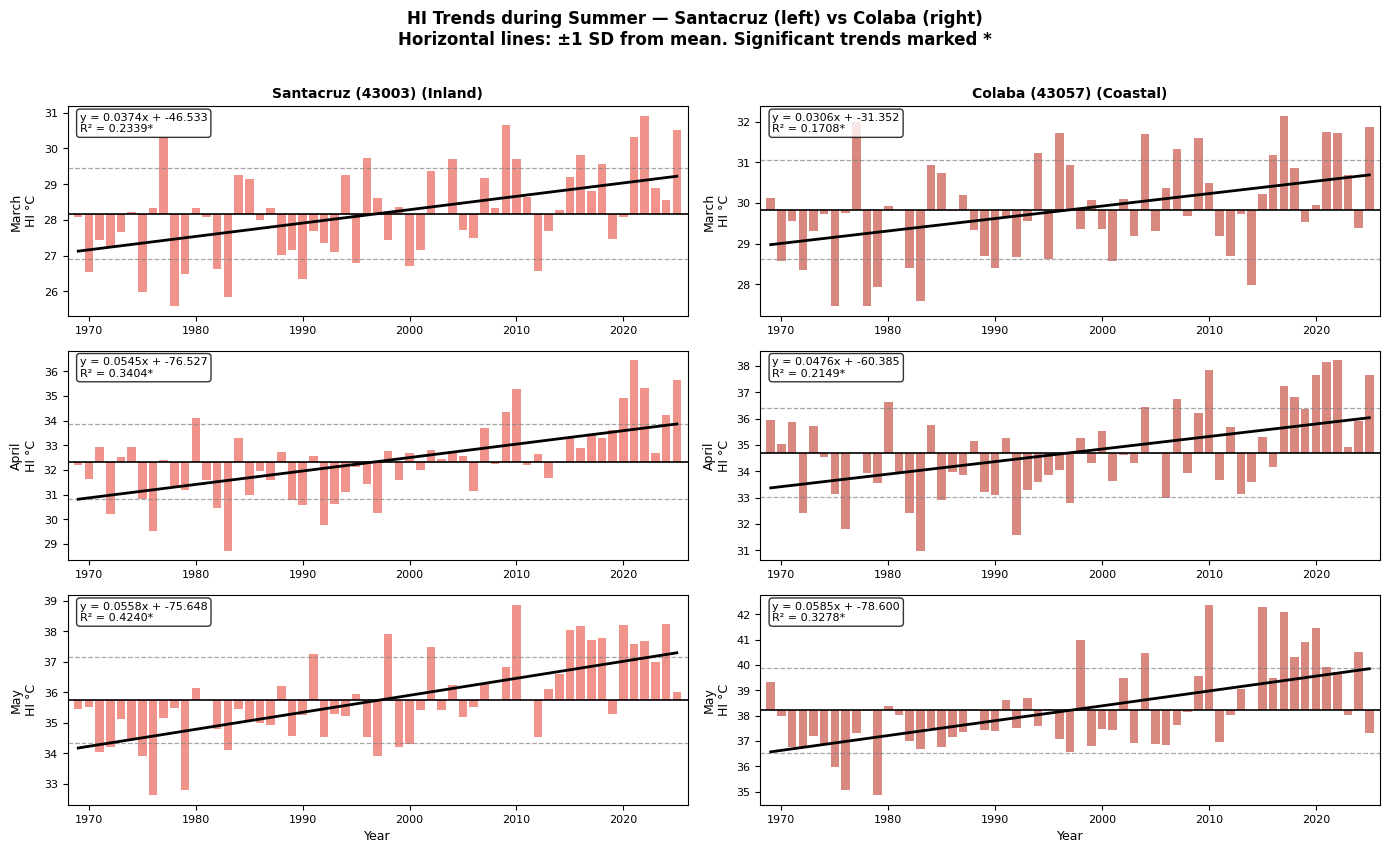

✅ Fig2 saved: paper_Fig2_monthly_HI_summer.png


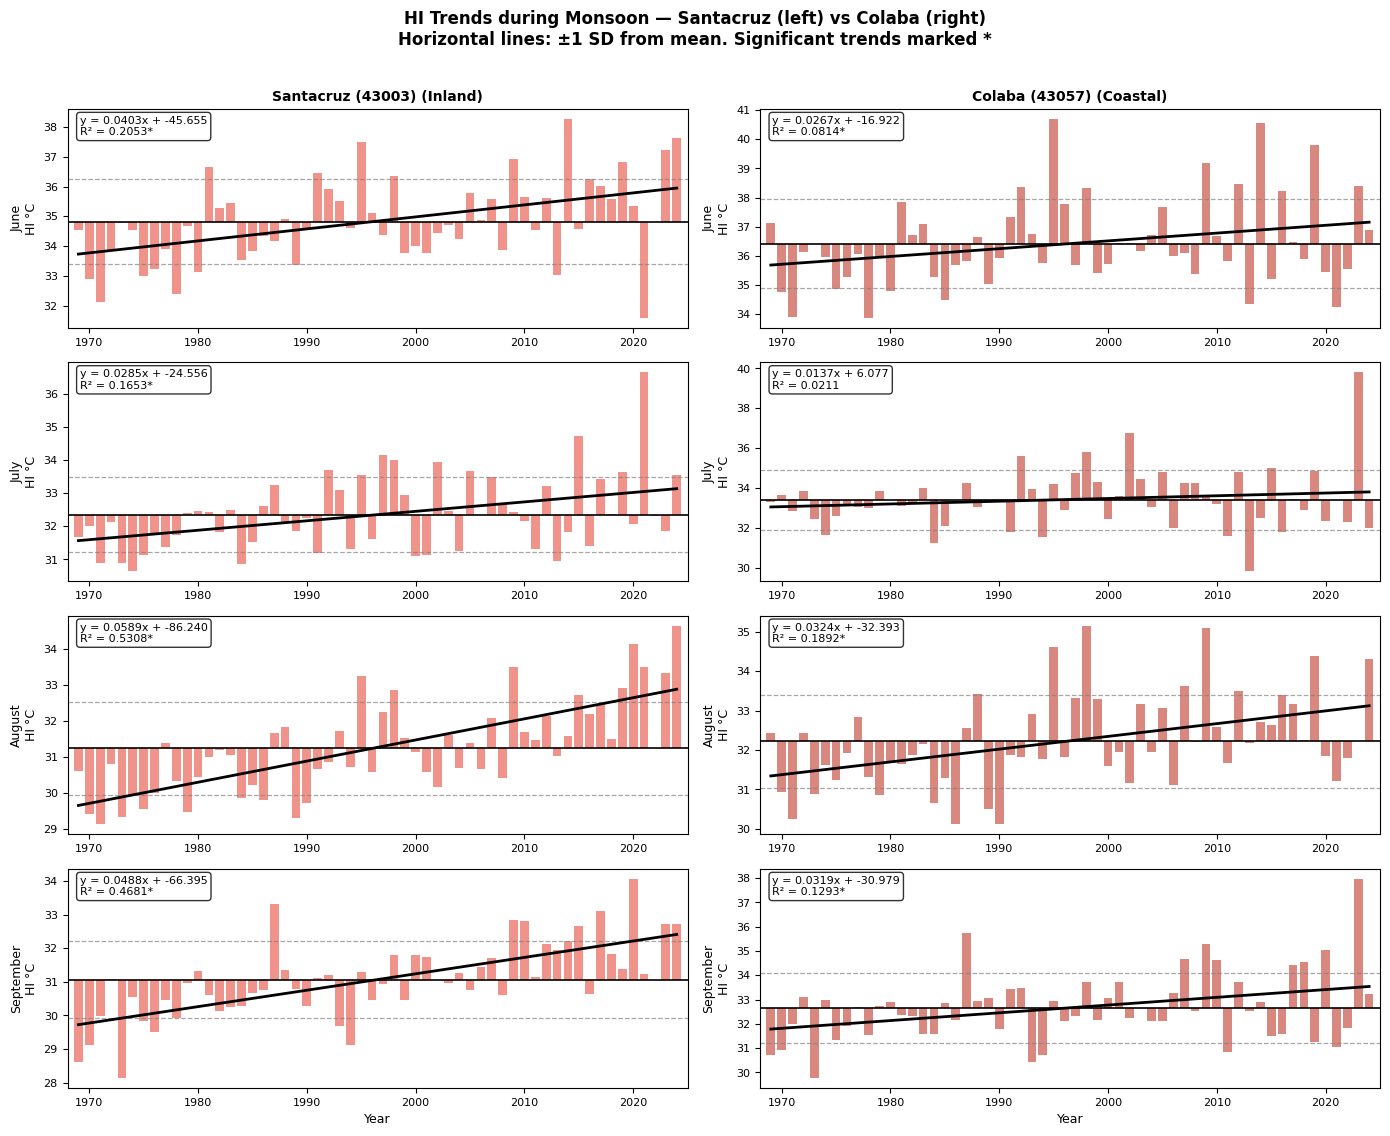

✅ Fig3 saved: paper_Fig3_monthly_HI_monsoon.png


In [ ]:
"""
===============================================================================
  PAPER FIG 2 & 3 — Monthly HI Trends: Summer + Monsoon
  Santacruz (left column) vs Colaba (right column)
  Each subplot: annual mean HI for that month with ±1 SD, trend line, R², sig*
===============================================================================
"""
def plot_monthly_trends(index_var, season_months, season_name, fig_label):
    """Plot monthly index trends side-by-side for both stations."""
    n_months = len(season_months)
    fig, axes = plt.subplots(n_months, 2, figsize=(14, n_months * 2.8))
    fig.suptitle(f'{index_var} Trends during {season_name} — '
                 f'Santacruz (left) vs Colaba (right)\n'
                 f'Horizontal lines: ±1 SD from mean. Significant trends marked *',
                 fontsize=12, fontweight='bold', y=1.01)

    for col_idx, (sid, meta) in enumerate(STATIONS.items()):
        df = dfs[sid]
        color = meta['color_hi'] if index_var == 'HI' else meta['color_pet']

        for row_idx, month in enumerate(season_months):
            ax = axes[row_idx][col_idx]
            month_df = df[df['MN'] == month]
            annual   = month_df.groupby('YEAR')[index_var].mean().dropna()

            if len(annual) < 5:
                ax.set_visible(False)
                continue

            years  = annual.index.values
            values = annual.values
            mean_v = values.mean()
            std_v  = values.std()

            # OLS regression
            slope, intercept, r_val, p_val, _ = stats.linregress(years, values)
            r2 = r_val**2
            sig = '*' if p_val < 0.05 else ''
            trend_line = slope * years + intercept

            # Plot time series as bar chart (paper style)
            # Normalise to mean for bar display
            ax.bar(years, values - mean_v, bottom=mean_v,
                   color=color, alpha=0.6, width=0.8, linewidth=0)
            ax.axhline(mean_v,         color='black', linewidth=1.2, linestyle='-')
            ax.axhline(mean_v + std_v, color='grey',  linewidth=0.9, linestyle='--', alpha=0.7)
            ax.axhline(mean_v - std_v, color='grey',  linewidth=0.9, linestyle='--', alpha=0.7)
            ax.plot(years, trend_line, color='black', linewidth=2.0, linestyle='-')

            eq = f'y = {slope:.4f}x + {intercept:.3f}\nR² = {r2:.4f}{sig}'
            ax.text(0.02, 0.97, eq, transform=ax.transAxes,
                    fontsize=8, va='top', ha='left',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

            # Station label only on top row
            if row_idx == 0:
                ax.set_title(f"{meta['label']} ({meta['type']})",
                             fontsize=10, fontweight='bold')
            ax.set_ylabel(f'{MONTH_NAMES[month]}\n{index_var} °C', fontsize=9)
            ax.set_xlabel('Year' if row_idx == n_months-1 else '', fontsize=9)
            ax.tick_params(labelsize=8)
            ax.set_xlim(years.min()-1, years.max()+1)

    plt.tight_layout()
    fname = os.path.join(OUTPUT_DIR, f'paper_{fig_label}_monthly_{index_var}_{season_name.lower().replace(" ","_")}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ {fig_label} saved: {os.path.basename(fname)}')


# Fig 2 equivalent — Summer HI trends (Mar, Apr, May)
plot_monthly_trends('HI', SUMMER, 'Summer', 'Fig2')

# Fig 3 equivalent — Monsoon HI trends (Jun, Jul, Aug, Sep)
plot_monthly_trends('HI', MONSOON, 'Monsoon', 'Fig3')

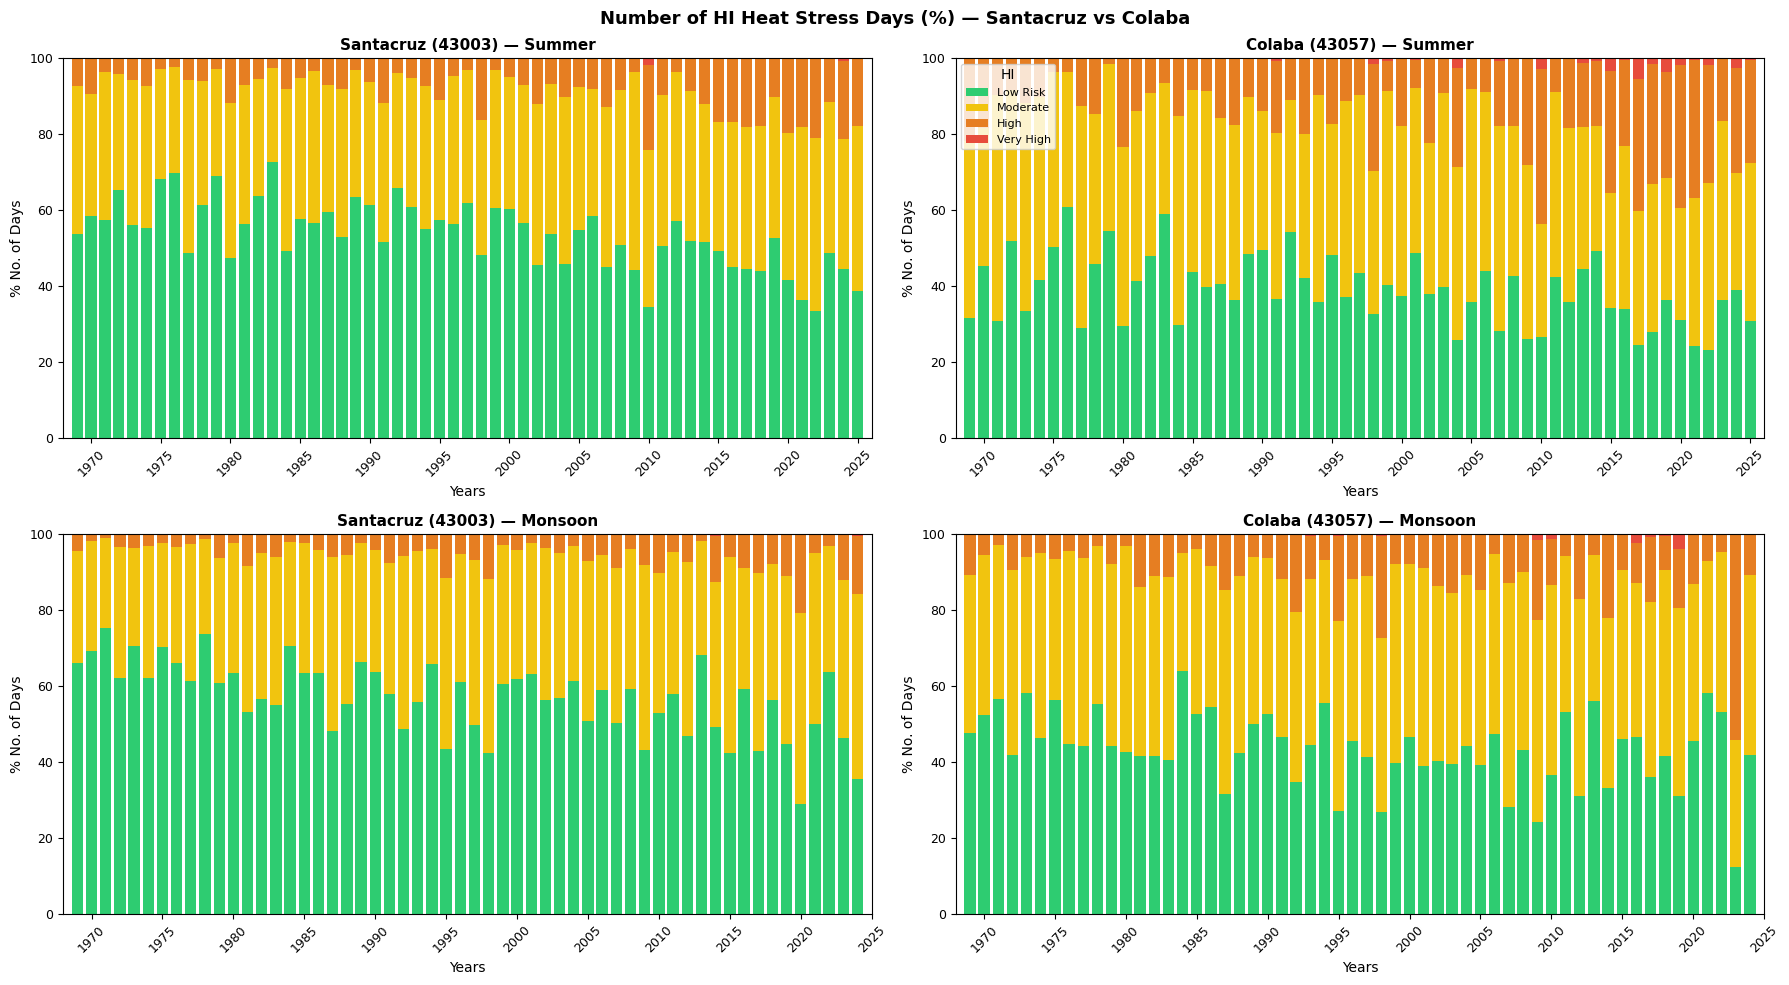

✅ Fig4_5 saved: paper_Fig4_5_perAnnum_HI.png


In [ ]:
"""
===============================================================================
  PAPER FIGS 4 & 5 — Per-Annum Heat Stress Day % Distribution (HI)
  Stacked bar: % of days in each HI category per year
  Summer (top) and Monsoon (bottom), both stations side-by-side
===============================================================================
"""
def plot_perAnnum_stacked(index_var, category_names, category_colors, fig_label):
    """Stacked bar charts: % category days per year for both stations."""
    cat_col = f'{index_var}_Category'
    n_cats  = len(category_names)
    seasons = [('Summer', SUMMER), ('Monsoon', MONSOON)]

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle(f'Number of {index_var} Heat Stress Days (%) — '
                 f'Santacruz vs Colaba',
                 fontsize=13, fontweight='bold')

    for s_idx, (season_name, months) in enumerate(seasons):
        for c_idx, (sid, meta) in enumerate(STATIONS.items()):
            ax = axes[s_idx][c_idx]
            df = dfs[sid]
            season_df = df[df['MN'].isin(months)]

            # Year-wise category percentages
            yearly = []
            for yr, grp in season_df.groupby('YEAR'):
                total = len(grp)
                if total < 10:
                    continue
                row = {'YEAR': yr}
                for cat in sorted(category_names.keys()):
                    row[category_names[cat]] = (grp[cat_col] == cat).sum() / total * 100
                yearly.append(row)

            if not yearly:
                continue
            ydf = pd.DataFrame(yearly).set_index('YEAR')

            # Stacked bars
            cat_labels = [category_names[c] for c in sorted(category_names.keys())]
            bottom = np.zeros(len(ydf))
            for i, (cat_name, color) in enumerate(zip(cat_labels, category_colors)):
                if cat_name in ydf.columns:
                    ax.bar(ydf.index, ydf[cat_name], bottom=bottom,
                           color=color, label=cat_name, width=0.8)
                    bottom += ydf[cat_name].values

            ax.set_xlim(ydf.index.min()-1, ydf.index.max()+1)
            ax.set_ylim(0, 100)
            ax.set_xlabel('Years', fontsize=10)
            ax.set_ylabel('% No. of Days', fontsize=10)
            ax.tick_params(labelsize=9)
            ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
            ax.tick_params(axis='x', rotation=45)

            title = f"{meta['label']} — {season_name}"
            ax.set_title(title, fontsize=11, fontweight='bold')

            if s_idx == 0 and c_idx == 1:
                ax.legend(loc='upper left', fontsize=8, ncol=1,
                          framealpha=0.8, title=index_var)

    plt.tight_layout()
    fname = os.path.join(OUTPUT_DIR, f'paper_{fig_label}_perAnnum_{index_var}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ {fig_label} saved: {os.path.basename(fname)}')


# Fig 4 & 5 equivalent — HI per-annum summer & monsoon
plot_perAnnum_stacked('HI', HI_NAMES, HI_COLORS, 'Fig4_5')

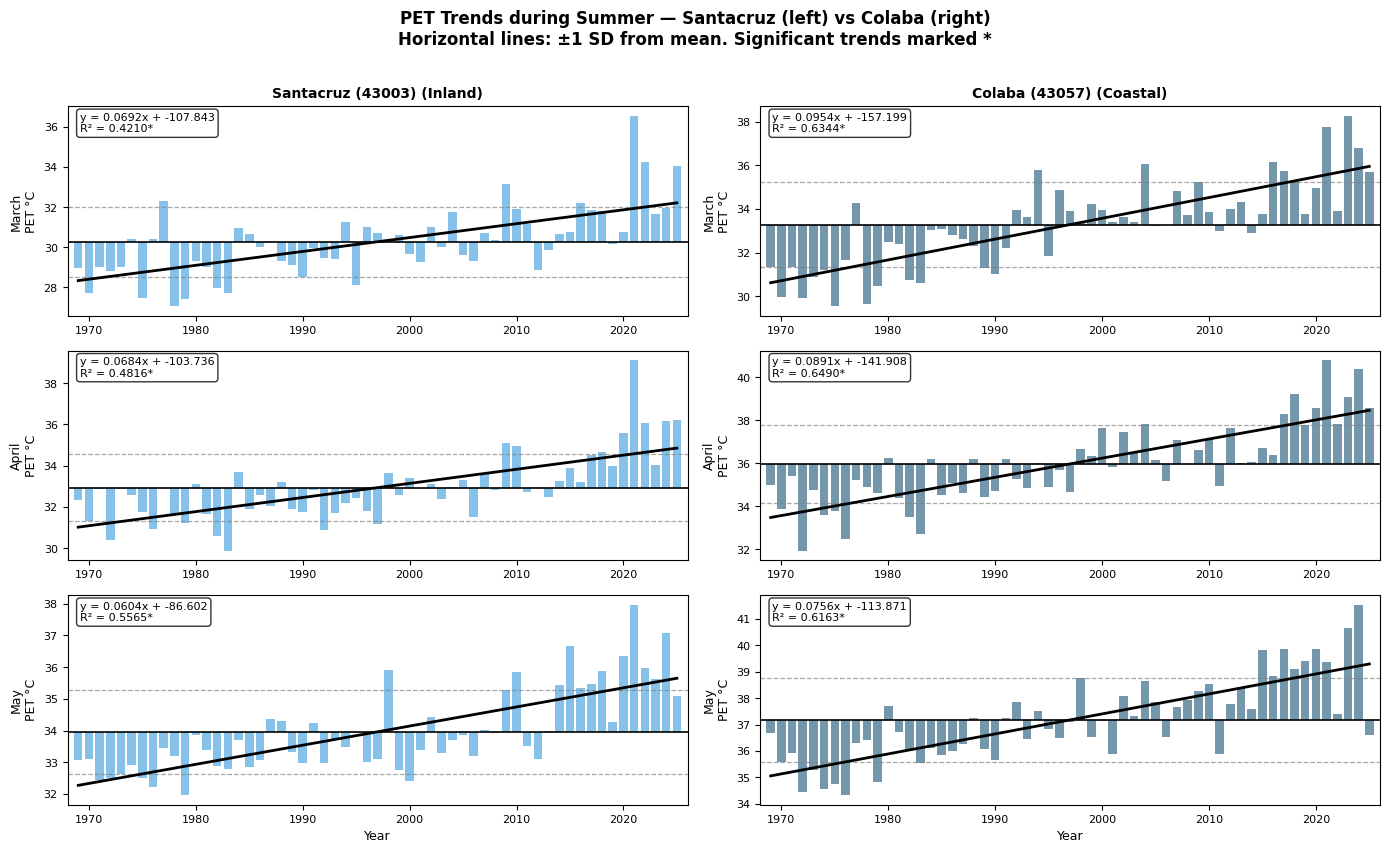

✅ Fig6 saved: paper_Fig6_monthly_PET_summer.png


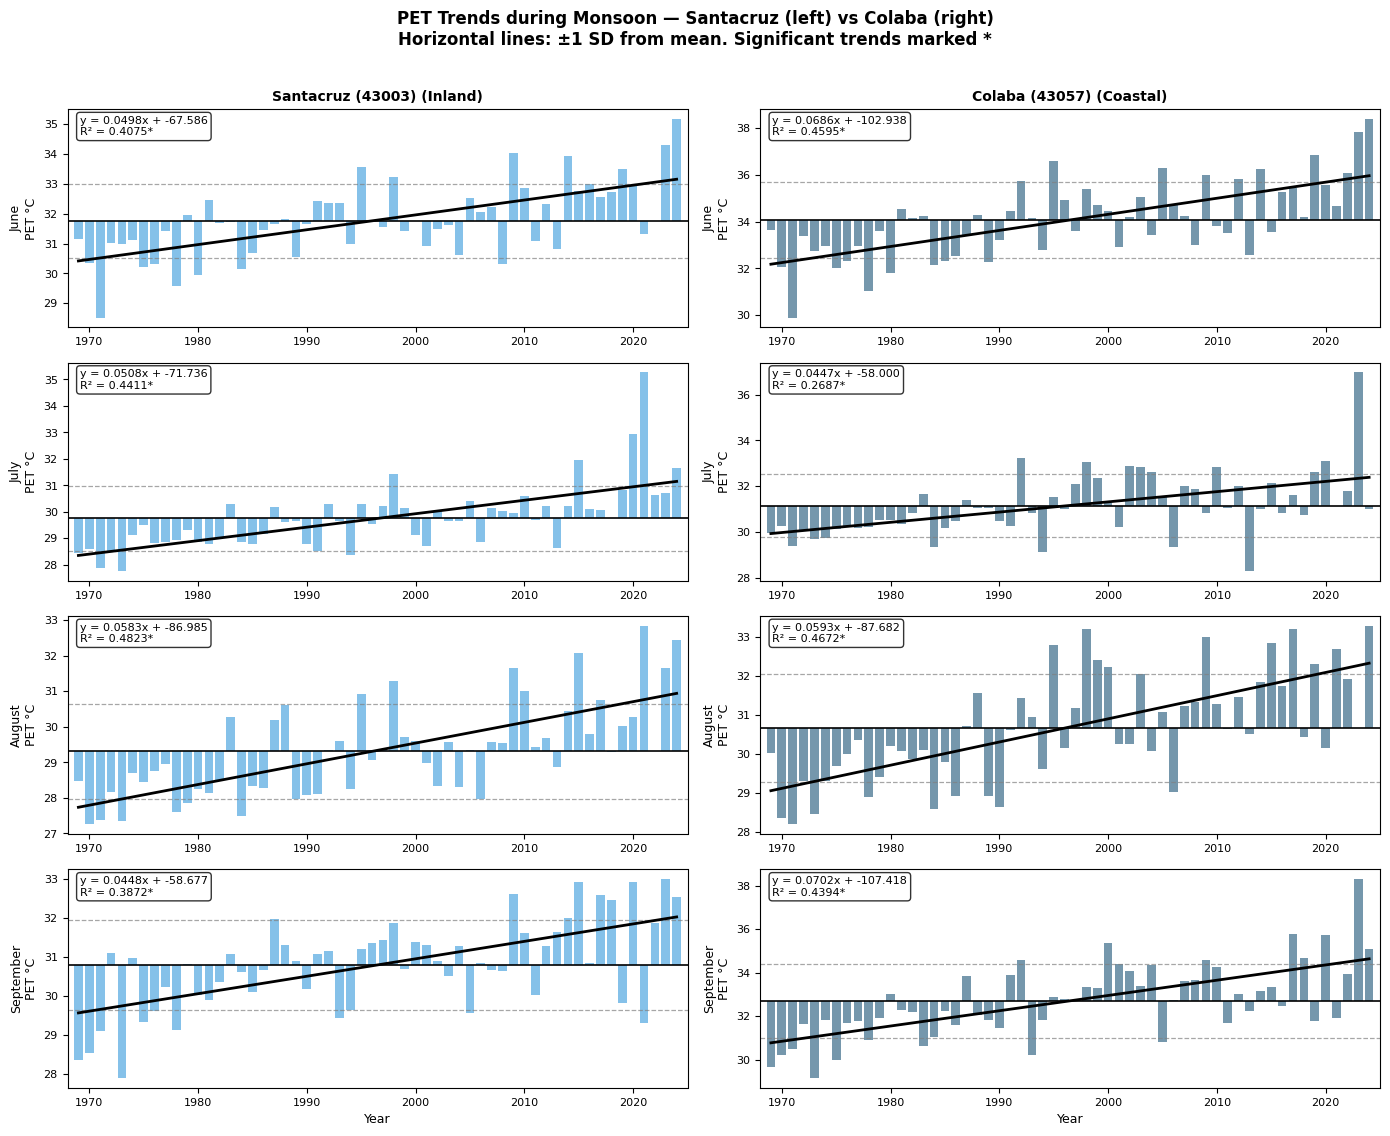

✅ Fig7 saved: paper_Fig7_monthly_PET_monsoon.png


In [ ]:
"""
===============================================================================
  PAPER FIGS 6 & 7 — Monthly PET Trends: Summer + Monsoon
===============================================================================
"""
# Fig 6 equivalent — Summer PET trends
plot_monthly_trends('PET', SUMMER, 'Summer', 'Fig6')

# Fig 7 equivalent — Monsoon PET trends
plot_monthly_trends('PET', MONSOON, 'Monsoon', 'Fig7')

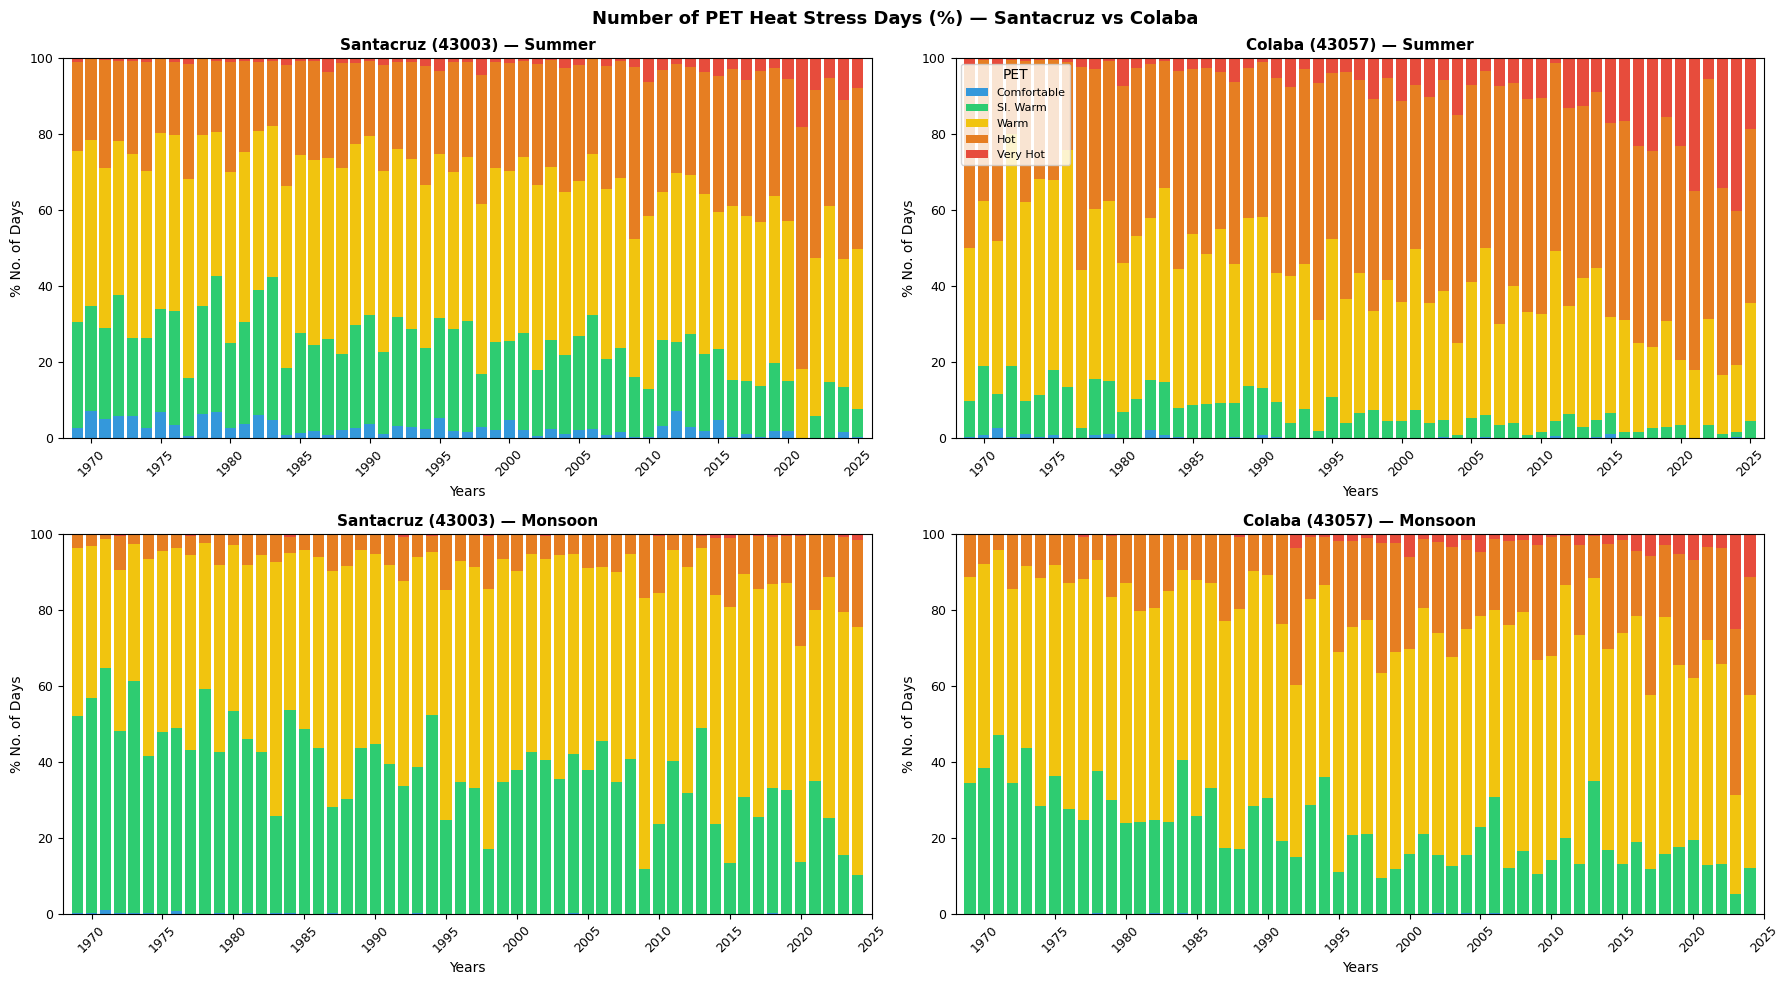

✅ Fig8_9 saved: paper_Fig8_9_perAnnum_PET.png


In [ ]:
"""
===============================================================================
  PAPER FIGS 8 & 9 — Per-Annum PET Heat Stress Day Distribution
===============================================================================
"""
plot_perAnnum_stacked('PET', PET_NAMES, PET_COLORS, 'Fig8_9')

In [ ]:
"""
===============================================================================
  PAPER TABLES 3–10 — Stepwise Multiple Regression
  For each station × season × index (HI/PET):
  Shows: Unstandardized B, Std Error, Standardized Beta, Pearson r, R², adj R²
  Matches Tables 3–10 structure from Desai et al. (2021)
===============================================================================
"""
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Predictors used in the paper's stepwise regression
PREDICTORS = ['DBT', 'WBT', 'DPT', 'RH', 'VP', 'FFF']

def stepwise_regression(df_season, y_col, predictor_cols, max_steps=4):
    """
    Forward stepwise regression matching Desai et al. approach.
    Returns DataFrame of final model coefficients.
    """
    from scipy.stats import t as t_dist, pearsonr

    data = df_season[predictor_cols + [y_col]].dropna()
    y = data[y_col].values
    n = len(y)
    ss_tot = np.sum((y - y.mean())**2)

    # Compute Pearson r for all predictors
    pearson_r = {col: pearsonr(data[col].values, y)[0] for col in predictor_cols}

    # Forward selection by highest |r| with y
    selected = []
    remaining = list(predictor_cols)

    # Step 1: pick highest |r|
    best = max(remaining, key=lambda c: abs(pearson_r[c]))
    selected.append(best)
    remaining.remove(best)

    # Steps 2+: add predictors that improve R² by ≥0.005
    for _ in range(min(max_steps-1, len(remaining))):
        if not remaining:
            break
        X_curr = data[selected].values
        X_curr = np.column_stack([np.ones(n), X_curr])
        beta_curr, _, _, _ = np.linalg.lstsq(X_curr, y, rcond=None)
        ss_res_curr = np.sum((y - X_curr @ beta_curr)**2)
        r2_curr = 1 - ss_res_curr / ss_tot if ss_tot > 0 else 0

        best_gain = 0
        best_next = None
        for cand in remaining:
            X_try = data[selected + [cand]].values
            X_try = np.column_stack([np.ones(n), X_try])
            beta_try, _, _, _ = np.linalg.lstsq(X_try, y, rcond=None)
            ss_res_try = np.sum((y - X_try @ beta_try)**2)
            r2_try = 1 - ss_res_try / ss_tot if ss_tot > 0 else 0
            gain = r2_try - r2_curr
            if gain > best_gain:
                best_gain = gain
                best_next = cand

        if best_next and best_gain >= 0.005:
            selected.append(best_next)
            remaining.remove(best_next)
        else:
            break

    # Final model OLS
    X_final = data[selected].values
    X_aug   = np.column_stack([np.ones(n), X_final])
    beta, _, _, _ = np.linalg.lstsq(X_aug, y, rcond=None)

    # R² and adj R²
    y_hat   = X_aug @ beta
    ss_res  = np.sum((y - y_hat)**2)
    r2      = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    p       = len(selected)
    adj_r2  = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    # Standard errors of coefficients
    mse     = ss_res / (n - p - 1)
    var_b   = mse * np.linalg.inv(X_aug.T @ X_aug).diagonal()
    se_b    = np.sqrt(var_b)

    # Standardized beta (beta * std_x / std_y)
    std_y = y.std()
    std_x = data[selected].std().values

    rows = []
    rows.append({'Variable': 'Constant', 'B': round(beta[0], 3),
                 'Std_Error': round(se_b[0], 3), 'Beta_Std': '',
                 'Pearson_r': '', 'Sig': ''})
    for i, var in enumerate(selected):
        b_val    = beta[i+1]
        se_val   = se_b[i+1]
        t_val    = b_val / se_val
        p_val    = 2 * (1 - t_dist.cdf(abs(t_val), df=n-p-1))
        beta_std = b_val * std_x[i] / std_y
        rows.append({
            'Variable':  var,
            'B':         round(b_val, 3),
            'Std_Error': round(se_val, 3),
            'Beta_Std':  round(beta_std, 3),
            'Pearson_r': round(pearson_r[var], 3),
            'Sig':       '*' if p_val < 0.05 else ''
        })

    result_df = pd.DataFrame(rows)
    result_df.attrs['R2']     = round(r2, 3)
    result_df.attrs['Adj_R2'] = round(adj_r2, 3)
    return result_df


# ── Run stepwise regression for all combinations ───────────────────────────
table_num = 3
all_tables = []

for sid, meta in STATIONS.items():
    df_station = dfs[sid].copy()
    df_summer  = df_station[df_station['MN'].isin(SUMMER)]
    df_monsoon = df_station[df_station['MN'].isin(MONSOON)]

    combos = [
        (df_summer,  'HI',  'Summer'),
        (df_summer,  'PET', 'Summer'),
        (df_monsoon, 'HI',  'Monsoon'),
        (df_monsoon, 'PET', 'Monsoon'),
    ]

    for df_s, idx, season in combos:
        print(f"\n{'='*70}")
        print(f"TABLE {table_num}  |  {idx} {season}  |  {meta['label']}")
        print(f"{'='*70}")
        reg = stepwise_regression(df_s, idx, PREDICTORS)
        print(reg.to_string(index=False))
        print(f"R² = {reg.attrs['R2']}    Adjusted R² = {reg.attrs['Adj_R2']}")
        print(f"* indicates significance at 0.05 level")
        reg.attrs.update({'Table': table_num, 'Station': meta['label'],
                          'Index': idx, 'Season': season})
        all_tables.append(reg)
        table_num += 1

print("\n✅ Stepwise regression complete (Tables 3–10)")


TABLE 3  |  HI Summer  |  Santacruz (43003)
Variable      B  Std_Error Beta_Std Pearson_r Sig
Constant -0.755      0.171                       
     DBT  0.819      0.006    0.524     0.914   *
      VP  0.680      0.004    0.655     0.578   *
      RH -0.130      0.002   -0.365    -0.292   *
R² = 0.964    Adjusted R² = 0.964
* indicates significance at 0.05 level

TABLE 4  |  PET Summer  |  Santacruz (43003)
Variable      B  Std_Error Beta_Std Pearson_r Sig
Constant -8.752      0.084                       
     DBT  1.491      0.003    1.073     0.885   *
     FFF -0.258      0.002   -0.335     0.267   *
R² = 0.86    Adjusted R² = 0.86
* indicates significance at 0.05 level

TABLE 5  |  HI Monsoon  |  Santacruz (43003)
Variable       B  Std_Error Beta_Std Pearson_r Sig
Constant -33.313      0.058                       
     DBT   1.827      0.002    0.905     0.968   *
      VP   0.462      0.002      0.2     0.487   *
R² = 0.974    Adjusted R² = 0.974
* indicates significance at 0.0

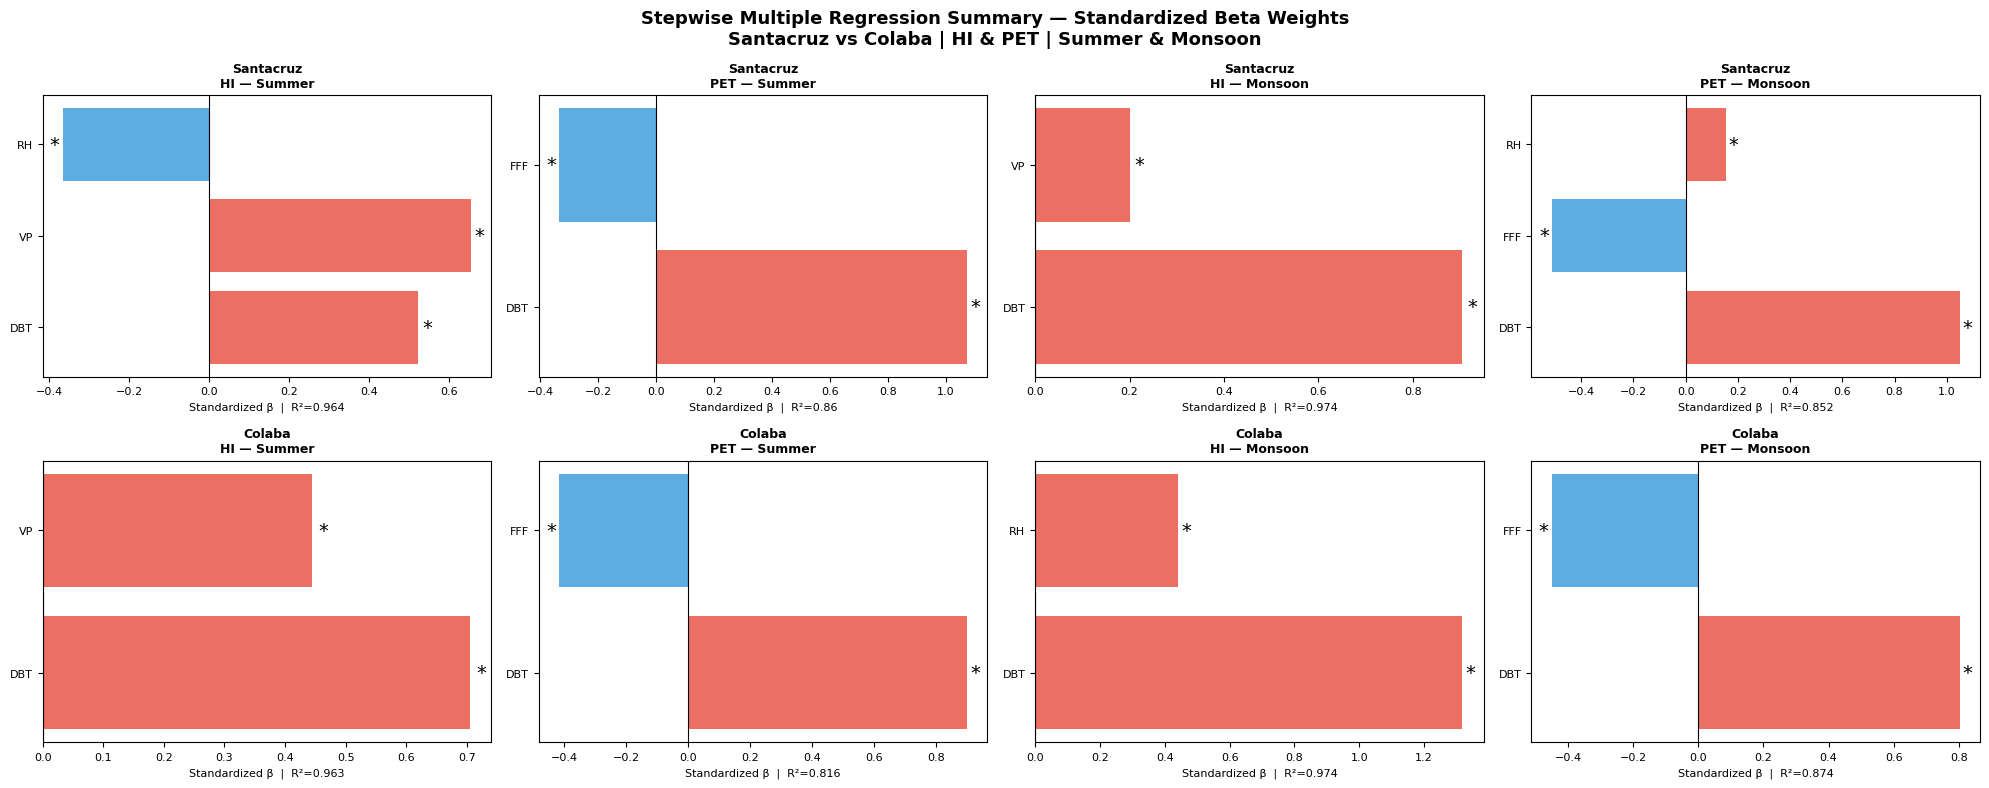

✅ Regression summary chart saved


In [ ]:
"""
===============================================================================
  REGRESSION TABLES — Visual Comparison Summary (Paper Style)
  Shows which meteorological parameters drive HI vs PET at each station
===============================================================================
"""
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Stepwise Multiple Regression Summary — Standardized Beta Weights\n'
             'Santacruz vs Colaba | HI & PET | Summer & Monsoon',
             fontsize=13, fontweight='bold')

for t_idx, tbl in enumerate(all_tables):
    ax = axes[t_idx // 4][t_idx % 4]
    reg_vars = tbl[tbl['Variable'] != 'Constant'].copy()
    reg_vars['Beta_Std'] = pd.to_numeric(reg_vars['Beta_Std'], errors='coerce')
    reg_vars = reg_vars.dropna(subset=['Beta_Std'])

    colors = ['#e74c3c' if v > 0 else '#3498db' for v in reg_vars['Beta_Std']]
    bars = ax.barh(reg_vars['Variable'], reg_vars['Beta_Std'], color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)

    # Add significance stars
    for i, (_, row) in enumerate(reg_vars.iterrows()):
        if row['Sig'] == '*':
            ax.text(row['Beta_Std'] + (0.01 if row['Beta_Std'] >= 0 else -0.01),
                    i, '*', va='center', ha='left' if row['Beta_Std'] >= 0 else 'right',
                    fontsize=14, color='black')

    r2   = tbl.attrs['R2']
    adj  = tbl.attrs['Adj_R2']
    lab  = tbl.attrs['Label'] if 'Label' in tbl.attrs else \
           f"{tbl.attrs['Station'].split('(')[0].strip()}\n{tbl.attrs['Index']} {tbl.attrs['Season']}"
    ax.set_title(f"{tbl.attrs['Station'].split('(')[0].strip()}\n"
                 f"{tbl.attrs['Index']} — {tbl.attrs['Season']}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel(f'Standardized β  |  R²={r2}', fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'paper_Tables3to10_regression_summary.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Regression summary chart saved')

---
## SECTION B — COMPARISON VISUALIZATIONS (Both Stations)
### All plots below show Santacruz vs Colaba side-by-side


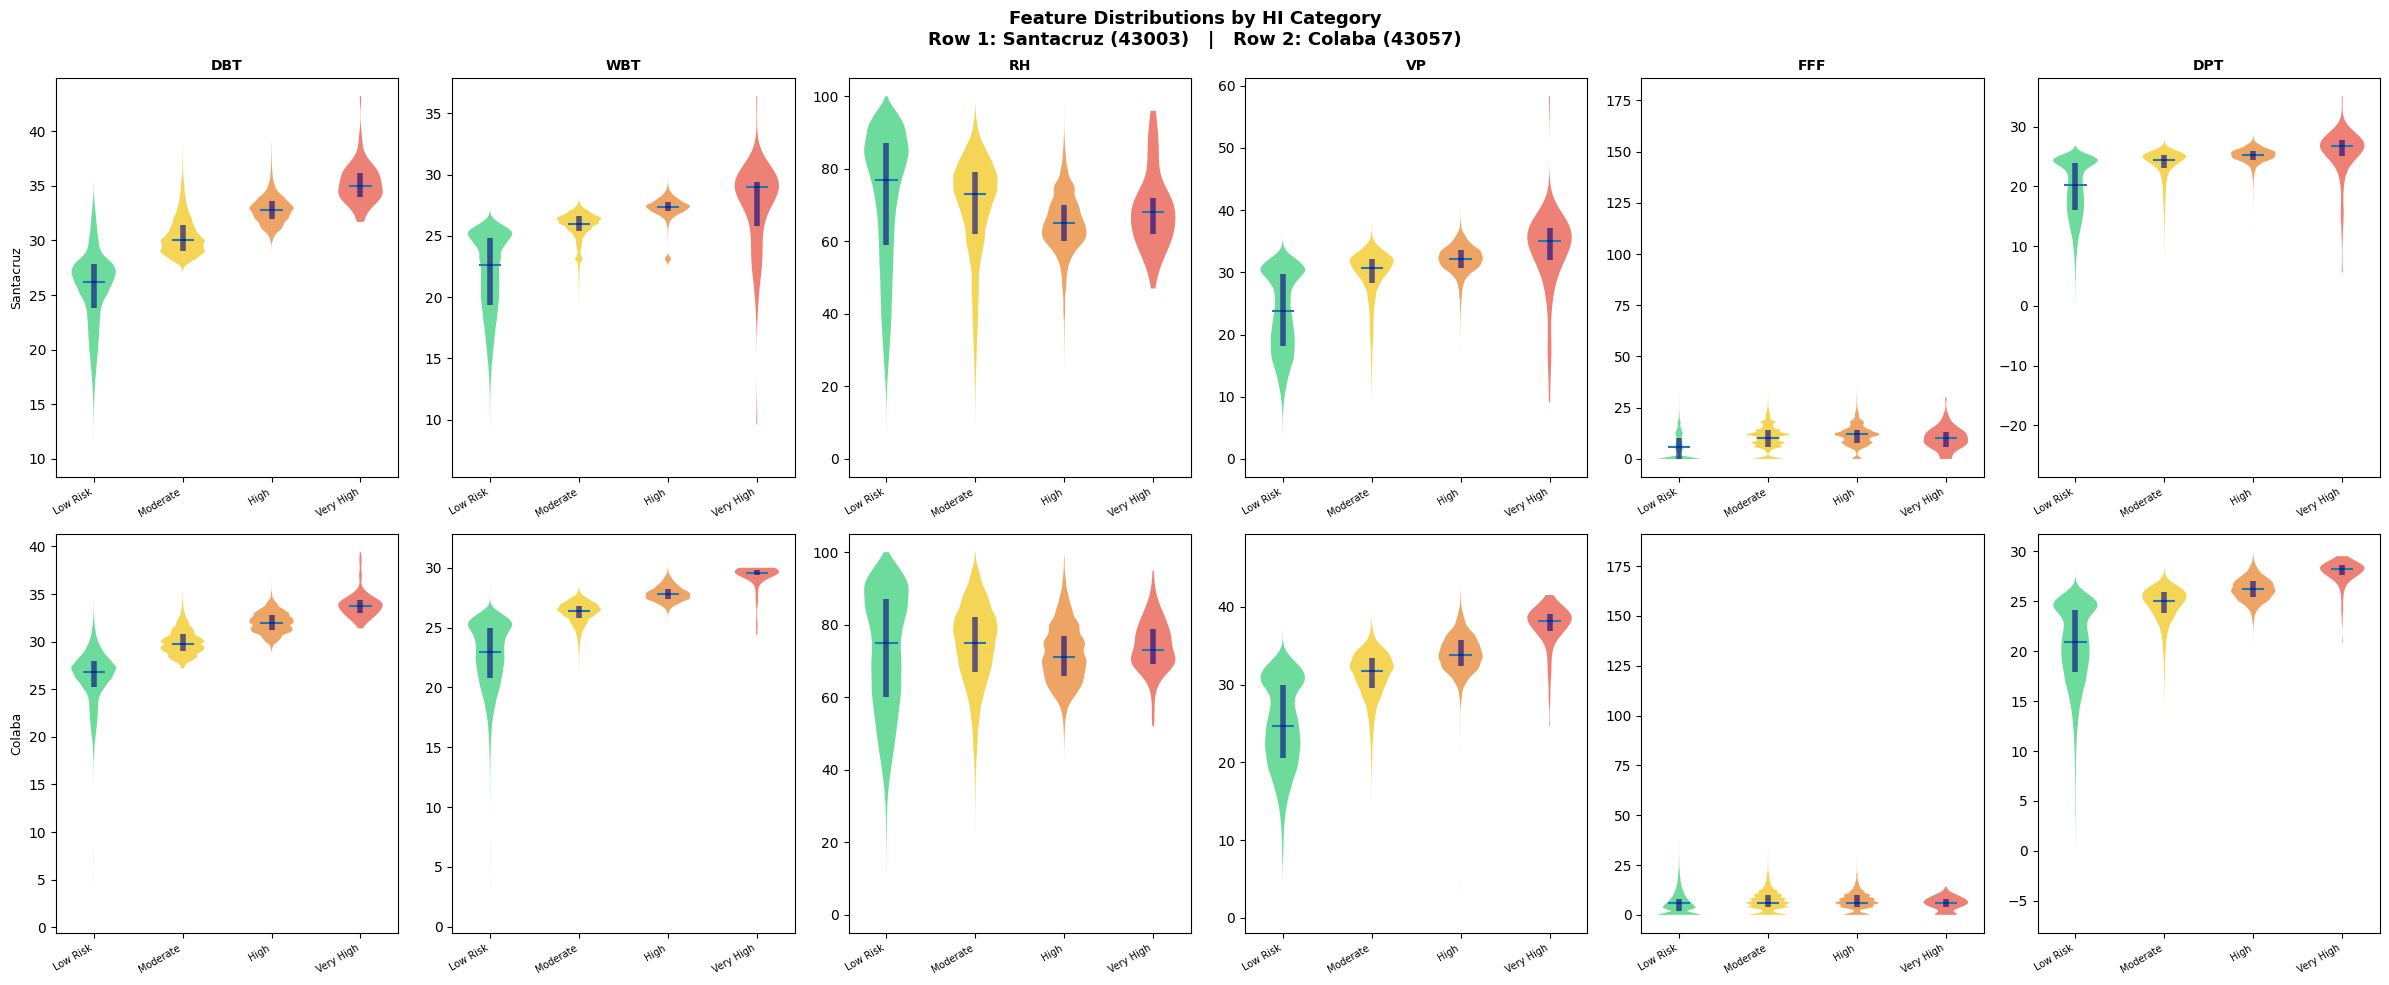

✅ Violin HI comparison saved


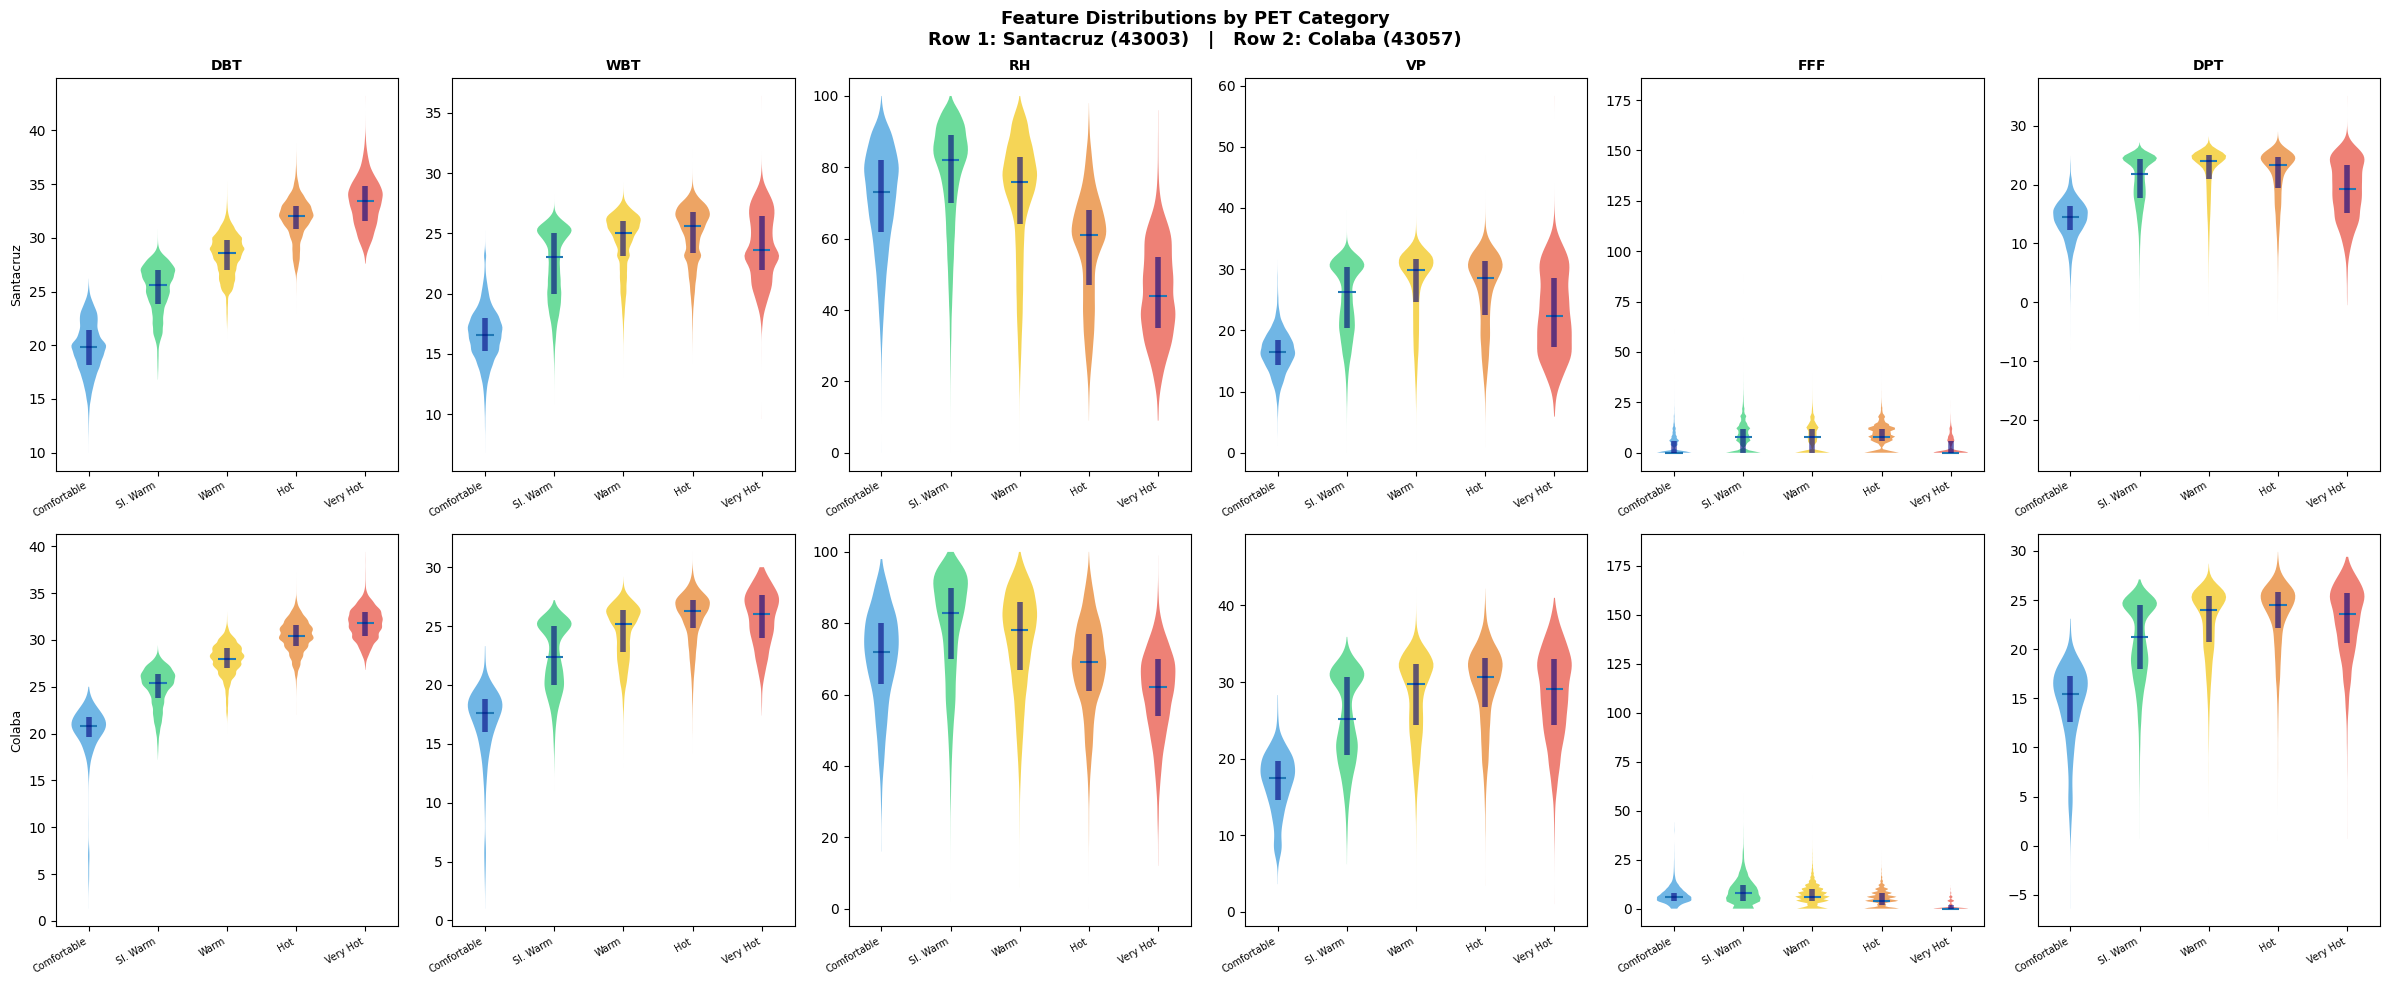

✅ Violin PET comparison saved


In [ ]:
"""
===============================================================================
  VIZ 1: VIOLIN PLOTS — Feature Distributions by HI/PET Category
  Both stations side-by-side
===============================================================================
"""
for target, names, colors, idx_label in [
    ('HI_Category',  HI_NAMES,  HI_COLORS,  'HI'),
    ('PET_Category', PET_NAMES, PET_COLORS, 'PET')]:

    feat_cols = ['DBT', 'WBT', 'RH', 'VP', 'FFF', 'DPT']
    fig, big_axes = plt.subplots(2, 6, figsize=(24, 10))
    fig.suptitle(f'Feature Distributions by {idx_label} Category\n'
                 f'Row 1: Santacruz (43003)   |   Row 2: Colaba (43057)',
                 fontsize=13, fontweight='bold')

    for row_i, (sid, meta) in enumerate(STATIONS.items()):
        df_c = cleans[sid]
        cats = sorted(df_c[target].unique())
        for col_i, feat in enumerate(feat_cols):
            ax = big_axes[row_i][col_i]
            data_list  = [df_c[df_c[target] == c][feat].dropna().values for c in cats]
            cat_labels = [names[c] for c in cats]
            parts = ax.violinplot(data_list, positions=range(len(cats)),
                                  showmedians=True, showextrema=False)
            for j, (pc, col) in enumerate(zip(parts['bodies'], [colors[c] for c in cats])):
                pc.set_facecolor(col)
                pc.set_alpha(0.7)
            for j, data in enumerate(data_list):
                q1, q3 = np.percentile(data, [25,75])
                ax.vlines(j, q1, q3, lw=4, color='navy', alpha=0.6)
            ax.set_xticks(range(len(cats)))
            ax.set_xticklabels(cat_labels, rotation=30, ha='right', fontsize=7)
            ax.set_title(f'{feat}' if row_i == 0 else '', fontsize=10, fontweight='bold')
            if col_i == 0:
                ax.set_ylabel(f"{meta['label'].split('(')[0].strip()}", fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'comparison_violin_{idx_label}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Violin {idx_label} comparison saved')

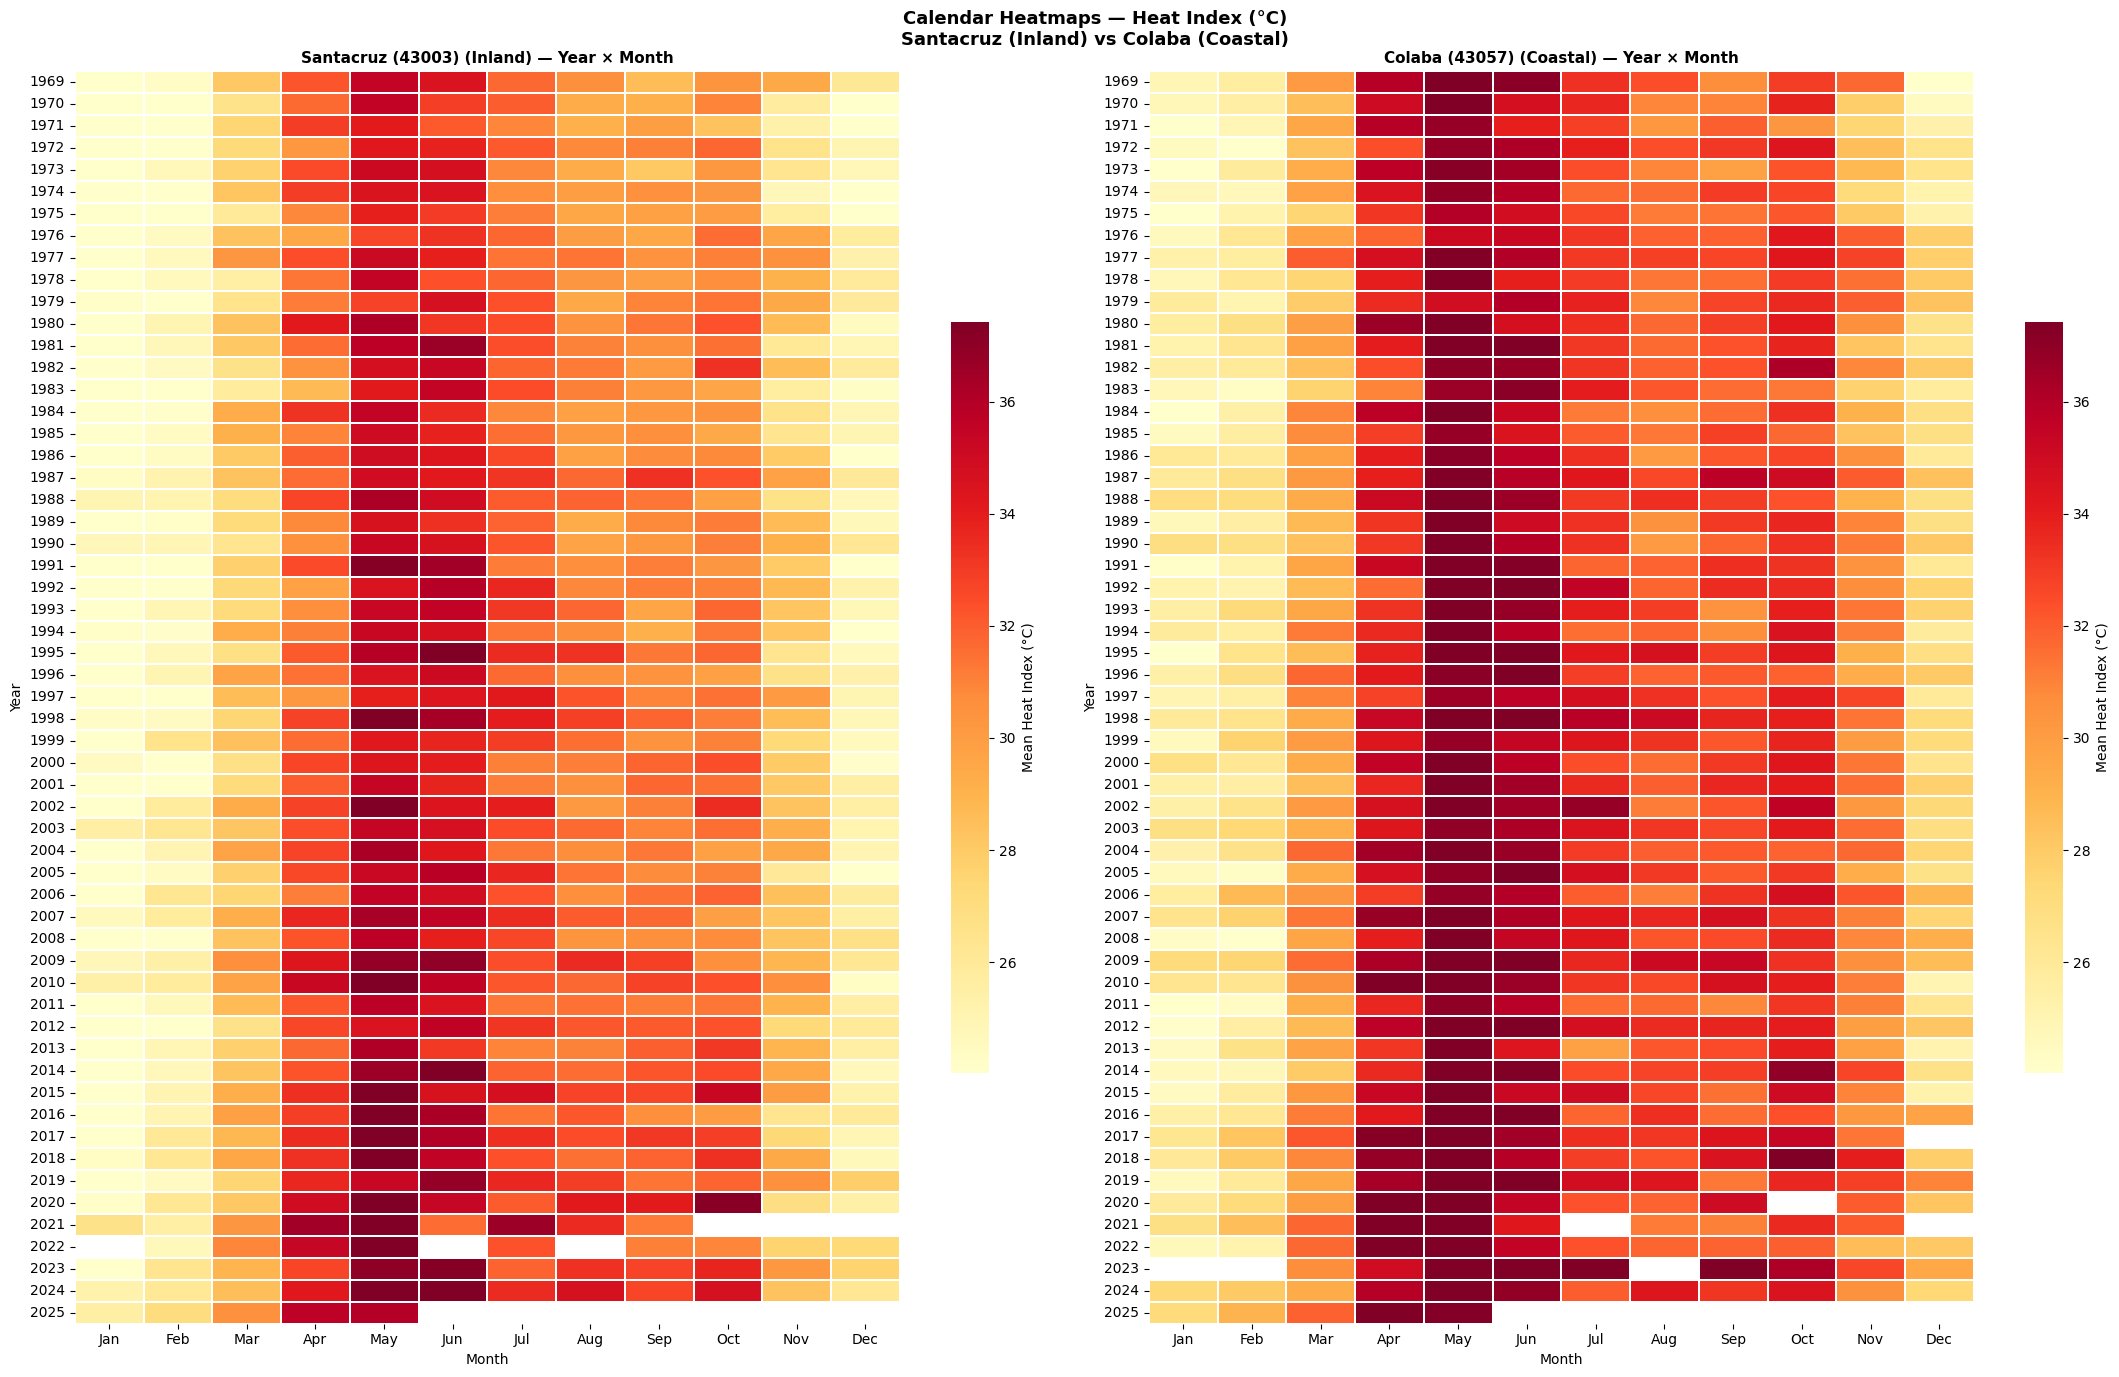

✅ Calendar heatmap HI saved


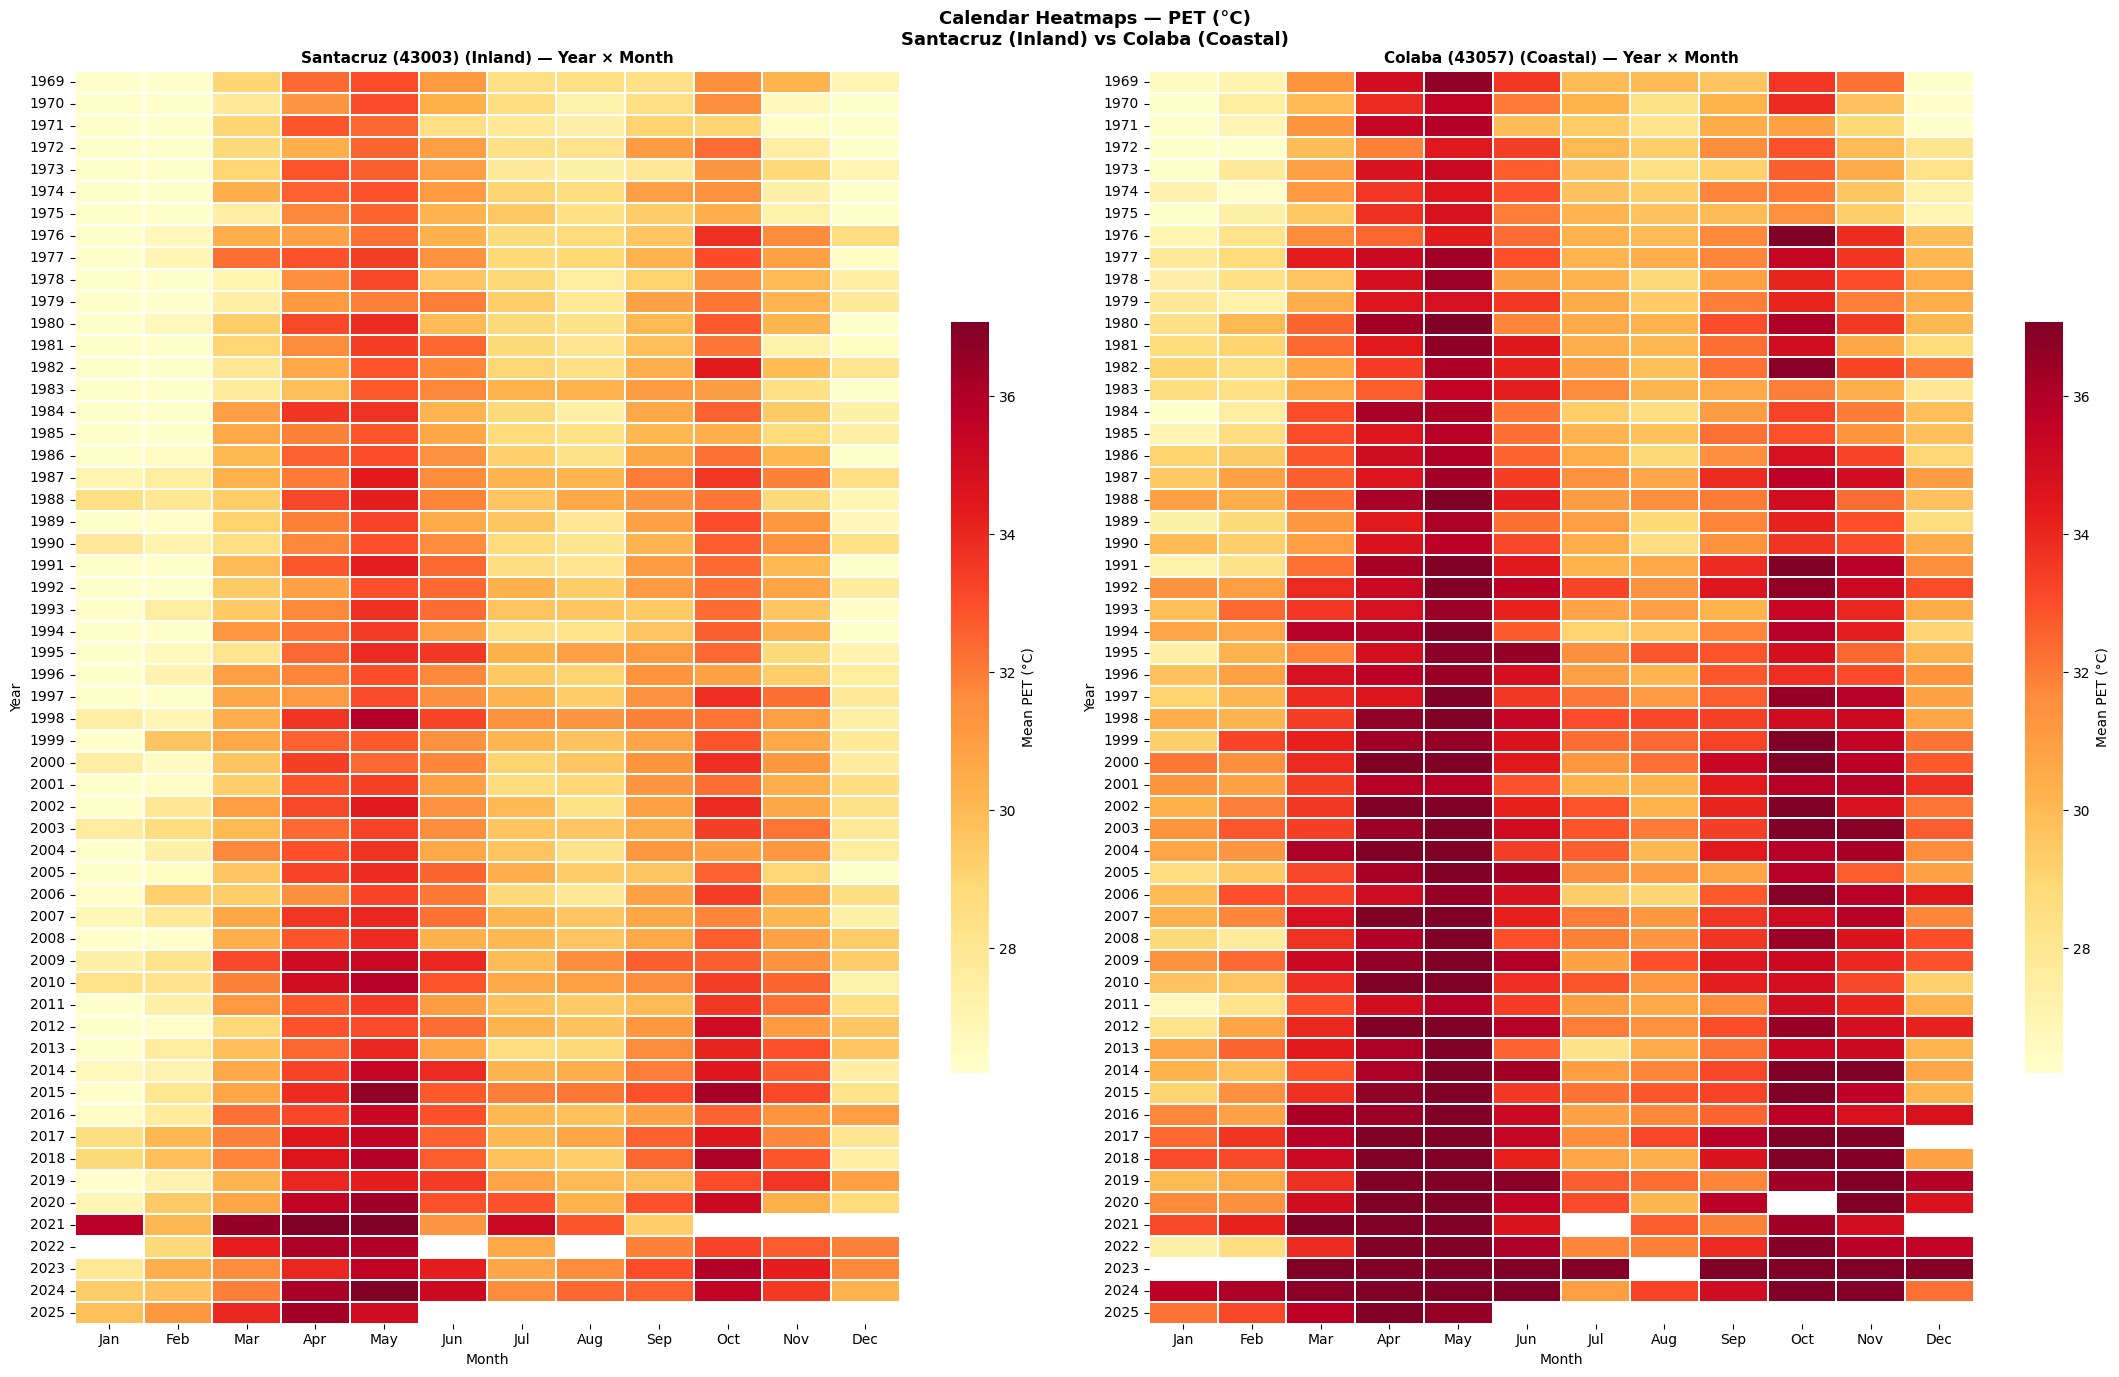

✅ Calendar heatmap PET saved


In [ ]:
"""
===============================================================================
  VIZ 2: CALENDAR HEATMAPS — Year × Month Mean HI & PET
  Both stations shown on same figure for direct visual comparison
===============================================================================
"""
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for var, label in [('HI','Heat Index'), ('PET','PET')]:
    fig, axes = plt.subplots(1, 2, figsize=(22, 14))
    fig.suptitle(f'Calendar Heatmaps — {label} (°C)\n'
                 f'Santacruz (Inland) vs Colaba (Coastal)',
                 fontsize=13, fontweight='bold')

    # Compute shared color scale
    all_vals = []
    for sid in STATIONS:
        pv = dfs[sid].groupby(['YEAR','MN'])[var].mean().reset_index()
        all_vals.extend(pv[var].dropna().values)
    vmin, vmax = np.percentile(all_vals, [5, 95])

    for ax, (sid, meta) in zip(axes, STATIONS.items()):
        pivot = dfs[sid].groupby(['YEAR','MN'])[var].mean().reset_index()
        pivot_mat = pivot.pivot(index='YEAR', columns='MN', values=var)
        sns.heatmap(pivot_mat, cmap='YlOrRd', ax=ax,
                    vmin=vmin, vmax=vmax,
                    linewidths=0.3, xticklabels=month_labels,
                    cbar_kws={'label': f'Mean {label} (°C)', 'shrink': 0.6})
        ax.set_title(f'{meta["label"]} ({meta["type"]}) — Year × Month',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Month'); ax.set_ylabel('Year')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'comparison_calendar_{var}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Calendar heatmap {var} saved')

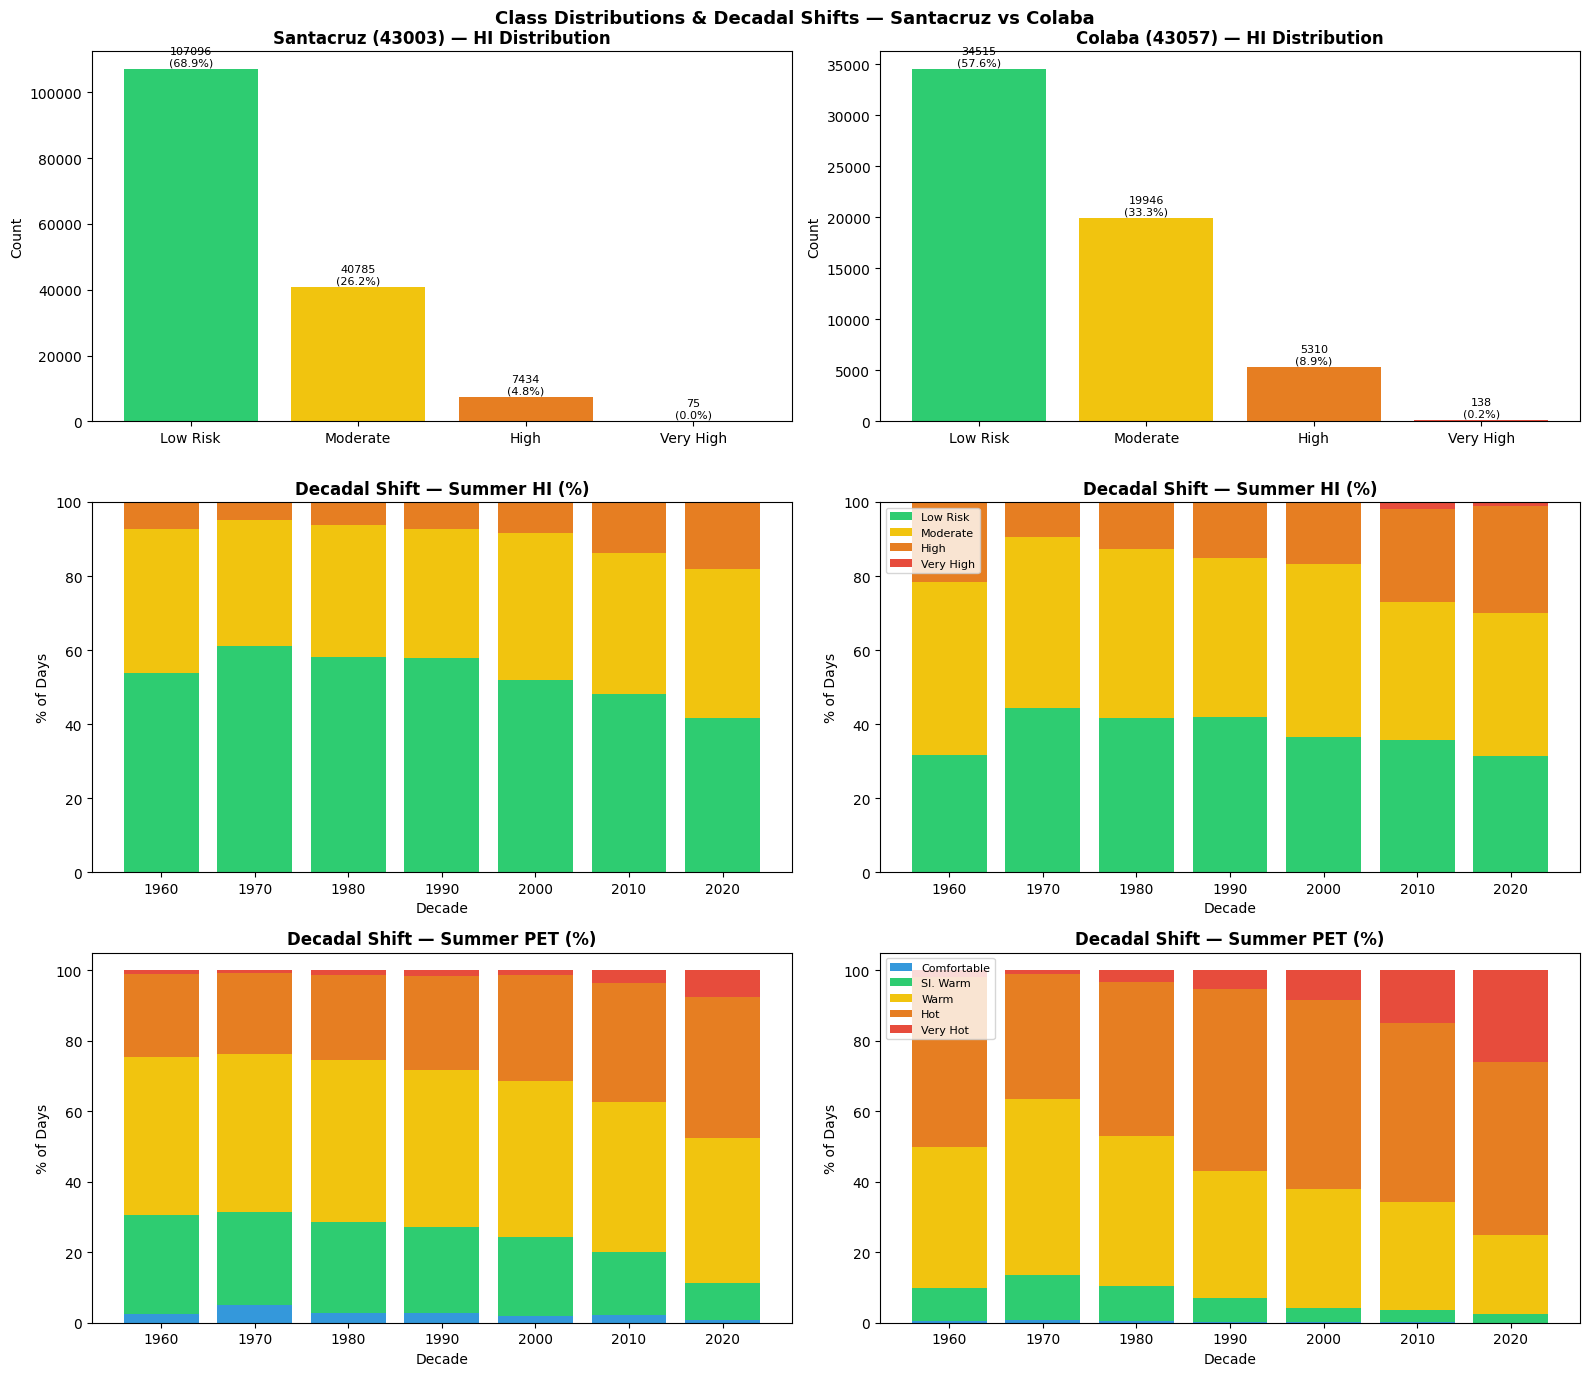

✅ Decadal distribution comparison saved


In [ ]:
"""
===============================================================================
  VIZ 3: DECADAL SHIFT + OVERALL DISTRIBUTION — Both Stations
===============================================================================
"""
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Class Distributions & Decadal Shifts — Santacruz vs Colaba',
             fontsize=13, fontweight='bold')

for col_i, (sid, meta) in enumerate(STATIONS.items()):
    df_c = cleans[sid]
    df_c = df_c.copy()
    df_c['Decade'] = (df_c['YEAR'] // 10) * 10

    # Row 0: Overall HI distribution
    ax = axes[0][col_i]
    hi_counts = df_c['HI_Category'].value_counts().sort_index()
    ax.bar([HI_NAMES[i] for i in hi_counts.index], hi_counts.values, color=HI_COLORS)
    ax.set_title(f'{meta["label"]} — HI Distribution', fontweight='bold')
    for i, v in enumerate(hi_counts.values):
        ax.text(i, v + hi_counts.values.max()*0.01,
                f'{v}\n({v/len(df_c)*100:.1f}%)', ha='center', fontsize=8)
    ax.set_ylabel('Count')

    # Row 1: Decadal HI shift (summer)
    ax = axes[1][col_i]
    summer_dc = df_c[df_c['MN'].isin(SUMMER)]
    decades = sorted(summer_dc['Decade'].unique())
    bottoms = np.zeros(len(decades))
    for cat, color in zip(sorted(HI_NAMES.keys()), HI_COLORS):
        vals = []
        for dec in decades:
            grp = summer_dc[summer_dc['Decade'] == dec]
            vals.append((grp['HI_Category'] == cat).sum() / max(len(grp),1) * 100)
        ax.bar(decades, vals, bottom=bottoms, color=color, label=HI_NAMES[cat], width=8)
        bottoms += np.array(vals)
    ax.set_title(f'Decadal Shift — Summer HI (%)', fontweight='bold')
    ax.set_ylabel('% of Days'); ax.set_xlabel('Decade')
    if col_i == 1:
        ax.legend(loc='upper left', fontsize=8)

    # Row 2: Decadal PET shift (summer)
    ax = axes[2][col_i]
    bottoms = np.zeros(len(decades))
    for cat, color in zip(sorted(PET_NAMES.keys()), PET_COLORS):
        vals = []
        for dec in decades:
            grp = summer_dc[summer_dc['Decade'] == dec]
            vals.append((grp['PET_Category'] == cat).sum() / max(len(grp),1) * 100)
        ax.bar(decades, vals, bottom=bottoms, color=color, label=PET_NAMES[cat], width=8)
        bottoms += np.array(vals)
    ax.set_title(f'Decadal Shift — Summer PET (%)', fontweight='bold')
    ax.set_ylabel('% of Days'); ax.set_xlabel('Decade')
    if col_i == 1:
        ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_decadal_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Decadal distribution comparison saved')

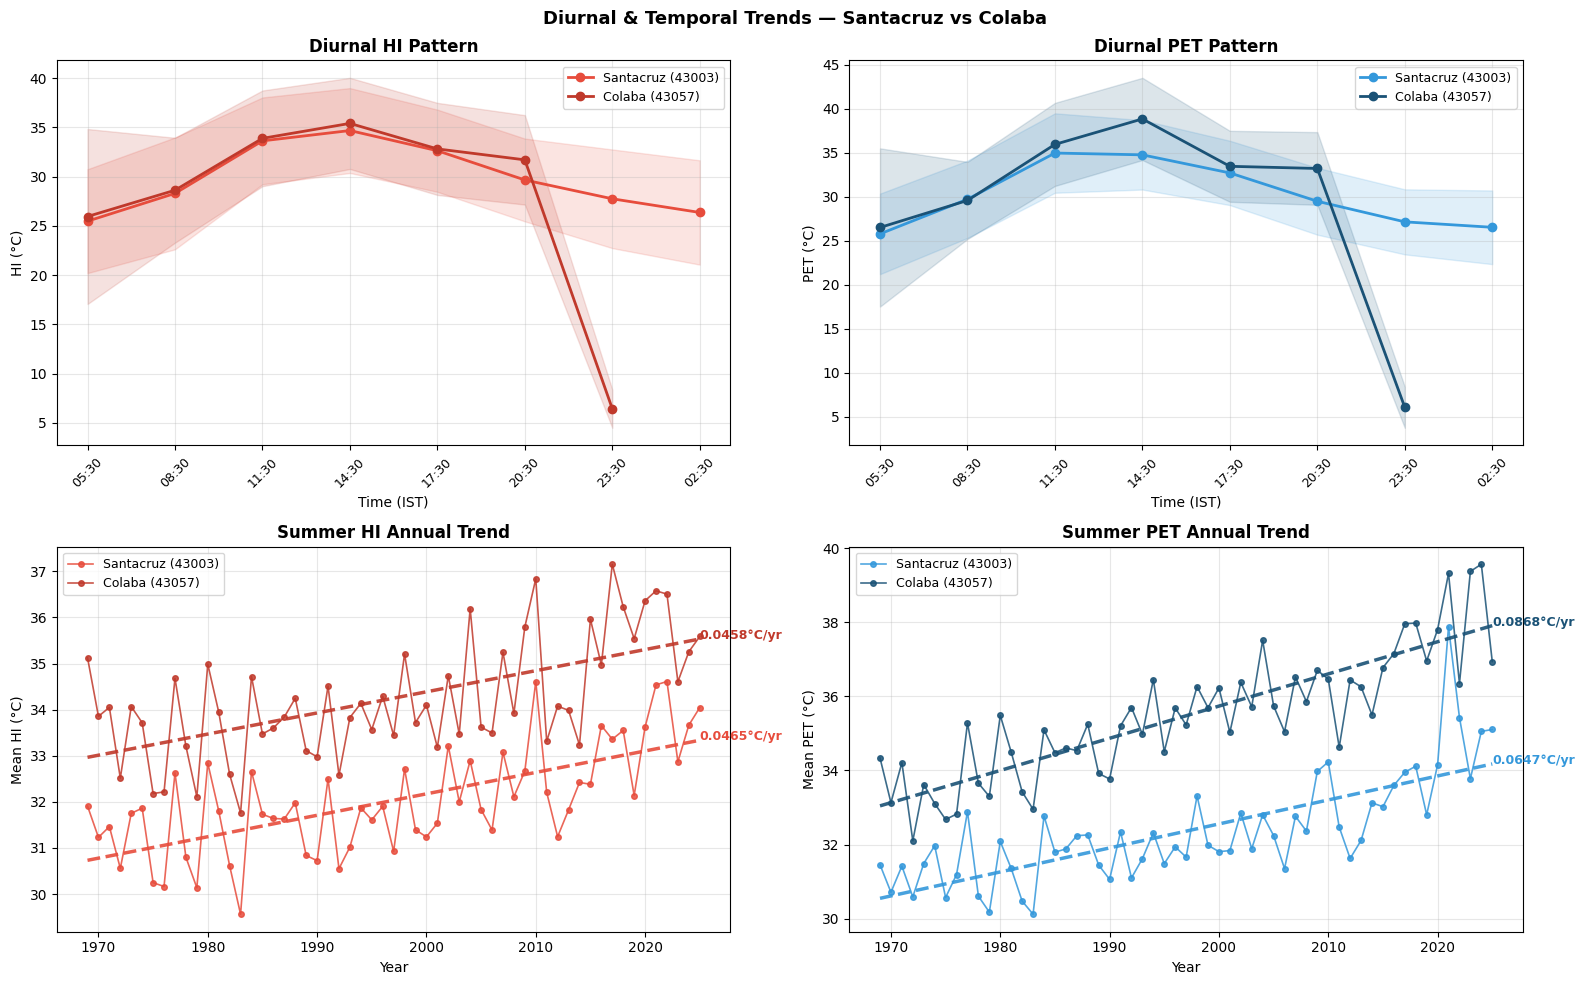

✅ Diurnal/temporal comparison saved


In [ ]:
"""
===============================================================================
  VIZ 4: DIURNAL + ANNUAL TRENDS — Both Stations Overlaid on Same Plot
===============================================================================
"""
hr_map = {0:'05:30', 12:'08:30', 24:'11:30', 36:'14:30',
          48:'17:30', 60:'20:30', 72:'23:30', 84:'02:30'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Diurnal & Temporal Trends — Santacruz vs Colaba',
             fontsize=13, fontweight='bold')

for var_i, var in enumerate(['HI', 'PET']):
    # ── Diurnal (top row) ──────────────────────────────────────
    ax = axes[0][var_i]
    x_ticks_set = False
    for sid, meta in STATIONS.items():
        df = dfs[sid]
        hourly = df.groupby('HR')[var].agg(['mean', 'std']).reset_index()
        hr_labels = [hr_map.get(h, str(h)) for h in hourly['HR']]
        x_pos = range(len(hourly))
        color = meta['color_hi'] if var == 'HI' else meta['color_pet']
        ax.plot(x_pos, hourly['mean'], 'o-', color=color,
                linewidth=2, markersize=6, label=meta['label'])
        ax.fill_between(x_pos,
                        hourly['mean'] - hourly['std'],
                        hourly['mean'] + hourly['std'],
                        alpha=0.15, color=color)
        if not x_ticks_set:
            ax.set_xticks(x_pos)
            ax.set_xticklabels(hr_labels, rotation=45, fontsize=9)
            x_ticks_set = True
    ax.set_title(f'Diurnal {var} Pattern', fontweight='bold')
    ax.set_xlabel('Time (IST)'); ax.set_ylabel(f'{var} (°C)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # ── Annual trend (bottom row) ───────────────────────────────
    ax = axes[1][var_i]
    for sid, meta in STATIONS.items():
        df = dfs[sid]
        summer_df = df[df['MN'].isin(SUMMER)]
        annual = summer_df.groupby('YEAR')[var].mean().dropna()
        color = meta['color_hi'] if var == 'HI' else meta['color_pet']
        ax.plot(annual.index, annual.values, 'o-', color=color,
                linewidth=1.2, markersize=4, label=meta['label'], alpha=0.85)
        z = np.polyfit(annual.index, annual.values, 1)
        ax.plot(annual.index, np.polyval(z, annual.index), '--',
                color=color, linewidth=2.5, alpha=0.9)
        ax.annotate(f"{z[0]:.4f}°C/yr",
                    xy=(annual.index[-1], np.polyval(z, annual.index[-1])),
                    fontsize=9, color=color, fontweight='bold')
    ax.set_title(f'Summer {var} Annual Trend', fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel(f'Mean {var} (°C)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_diurnal_temporal.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Diurnal/temporal comparison saved')

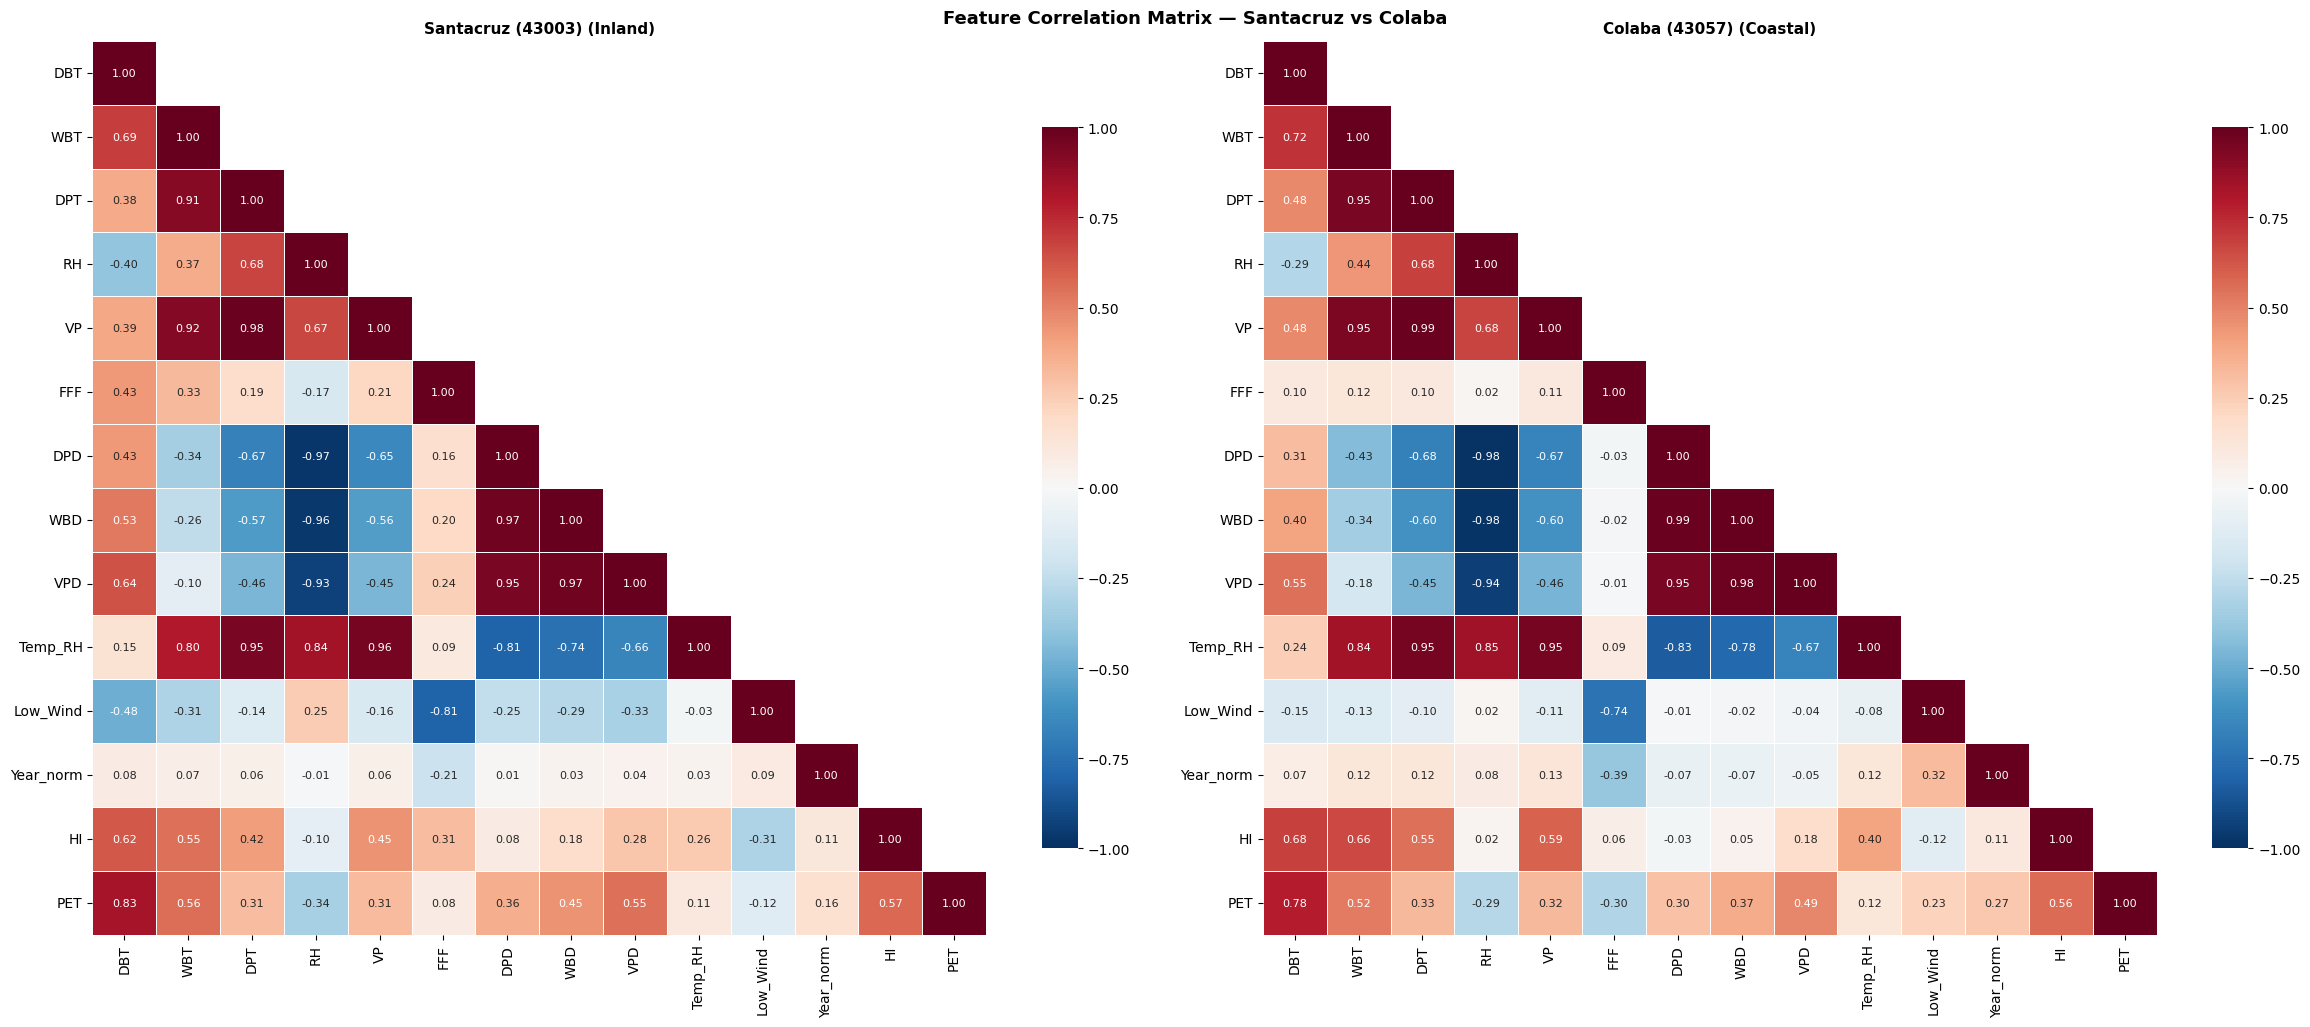

✅ Correlation comparison saved


In [ ]:
"""
===============================================================================
  VIZ 5: CORRELATION HEATMAPS — Both Stations Side-by-Side
===============================================================================
"""
corr_cols = RAW_MET + DERIVED + ['HI_Category', 'PET_Category']
rename_map = {'HI_Category': 'HI', 'PET_Category': 'PET'}

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
fig.suptitle('Feature Correlation Matrix — Santacruz vs Colaba',
             fontsize=13, fontweight='bold')

for ax, (sid, meta) in zip(axes, STATIONS.items()):
    df_c = cleans[sid].copy()
    df_c = df_c.rename(columns=rename_map)
    available = [c if c not in rename_map else rename_map[c]
                 for c in corr_cols if c in df_c.columns or rename_map.get(c) in df_c.columns]
    corr_data = df_c[[c for c in available if c in df_c.columns]]
    corr_matrix = corr_data.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                mask=mask, square=True, ax=ax, linewidths=0.5,
                cbar_kws={'shrink': 0.8}, annot_kws={'size': 8},
                vmin=-1, vmax=1)
    ax.set_title(f'{meta["label"]} ({meta["type"]})',
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_correlation.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Correlation comparison saved')

Running t-SNE for both stations (2–3 min)...


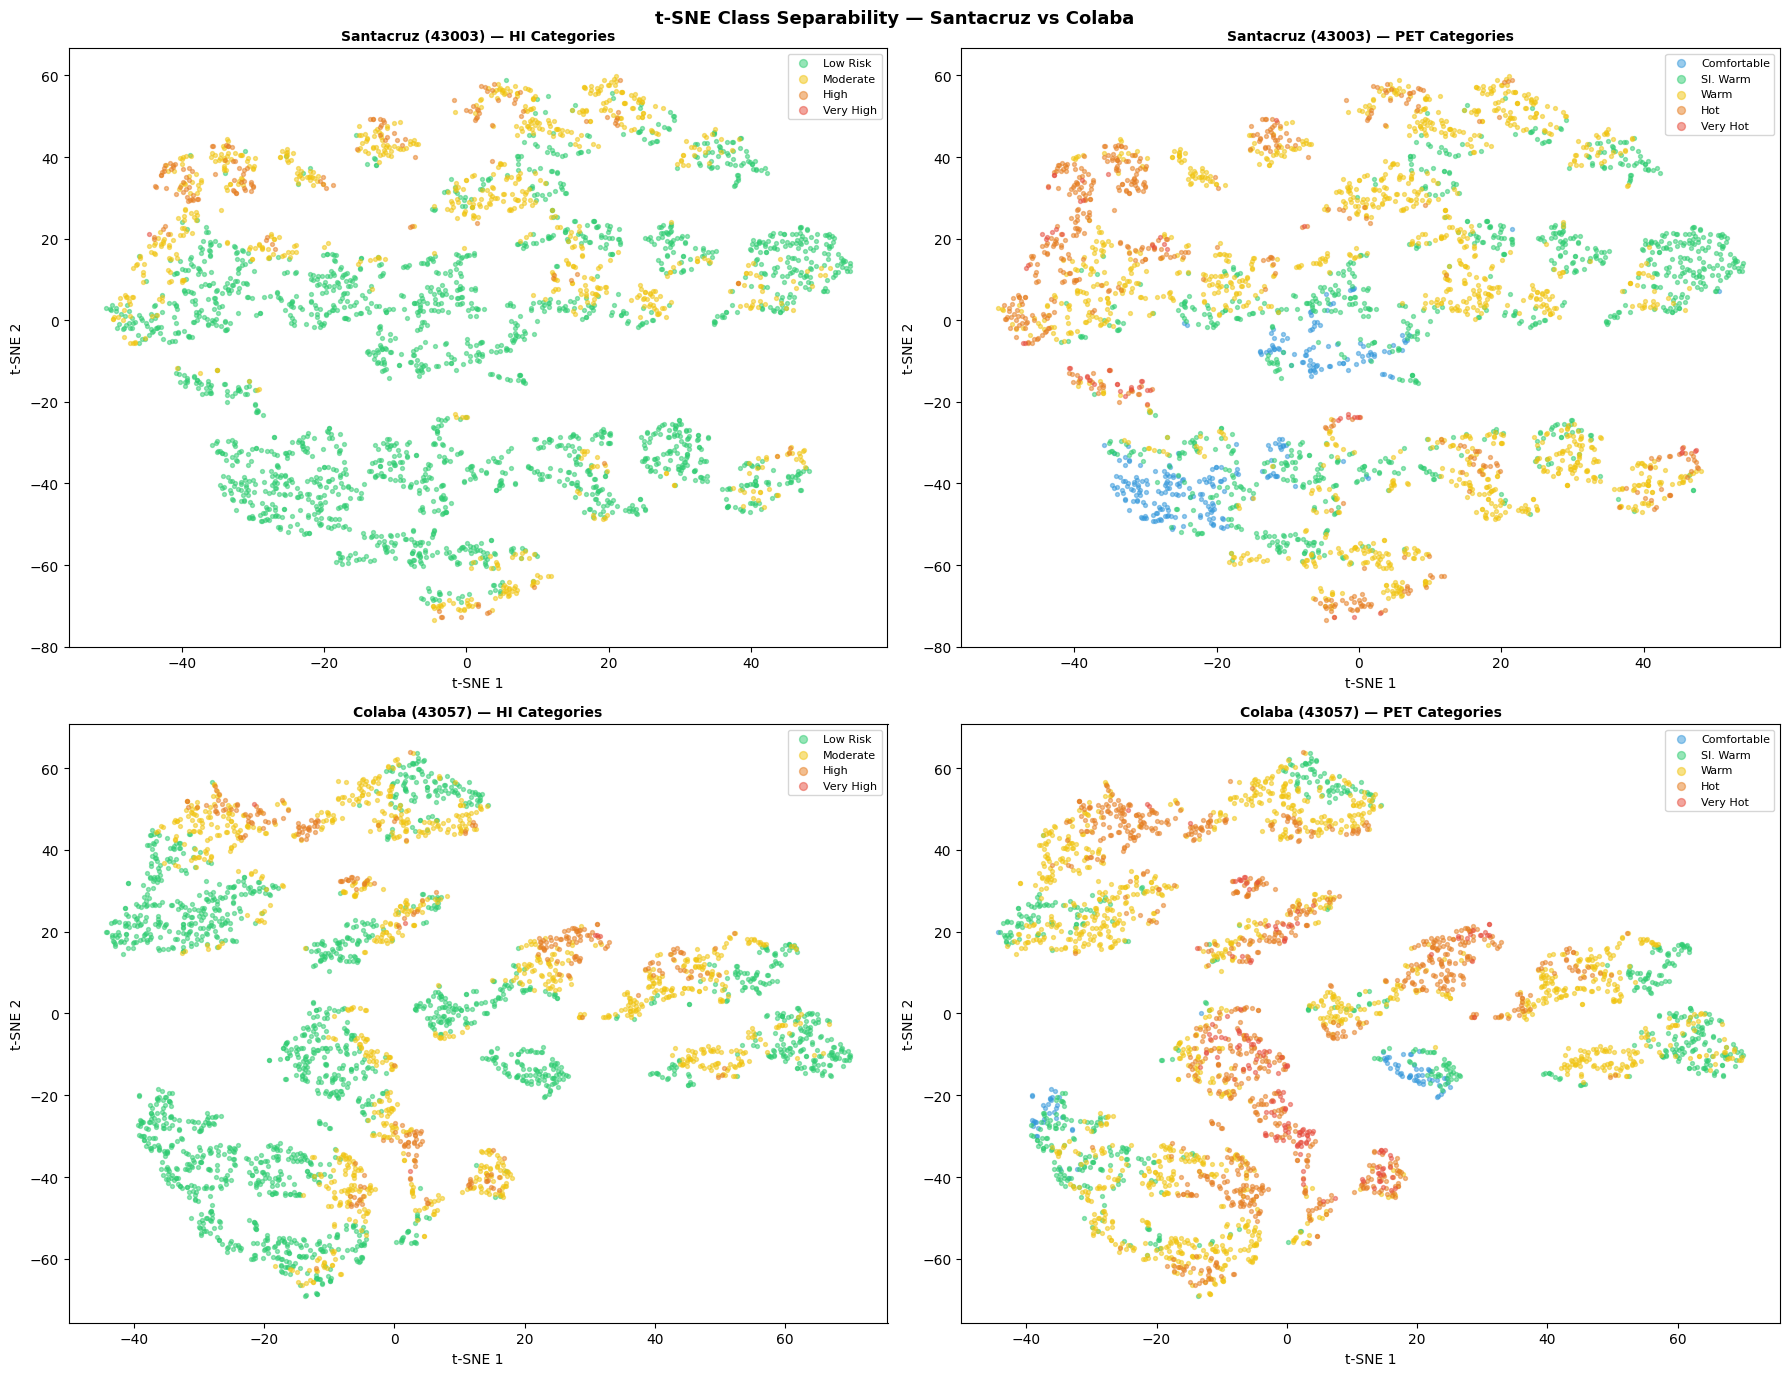

✅ t-SNE comparison saved


In [ ]:
"""
===============================================================================
  VIZ 6: t-SNE — Both Stations Side-by-Side
===============================================================================
"""
print('Running t-SNE for both stations (2–3 min)...')
scaler = StandardScaler()
tsne_n = 3000

fig, big_axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('t-SNE Class Separability — Santacruz vs Colaba',
             fontsize=13, fontweight='bold')

for row_i, (sid, meta) in enumerate(STATIONS.items()):
    df_c = cleans[sid]
    X_s  = scaler.fit_transform(df_c[ALL_FEATURES].values)
    np.random.seed(42)
    idx  = np.random.choice(len(X_s), size=min(tsne_n, len(X_s)), replace=False)
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    X_2d = tsne.fit_transform(X_s[idx])

    for col_i, (cat_col, names, colors) in enumerate([
        ('HI_Category',  HI_NAMES,  HI_COLORS),
        ('PET_Category', PET_NAMES, PET_COLORS)]):
        ax = big_axes[row_i][col_i]
        y_sub = df_c[cat_col].values[idx]
        for cat in sorted(np.unique(y_sub)):
            mask = y_sub == cat
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c=colors[cat], s=8, alpha=0.5, label=names[cat])
        ax.set_title(f"{meta['label']} — {'HI' if col_i==0 else 'PET'} Categories",
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
        ax.legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_tsne.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ t-SNE comparison saved')


  SHAP — Santacruz (43003)


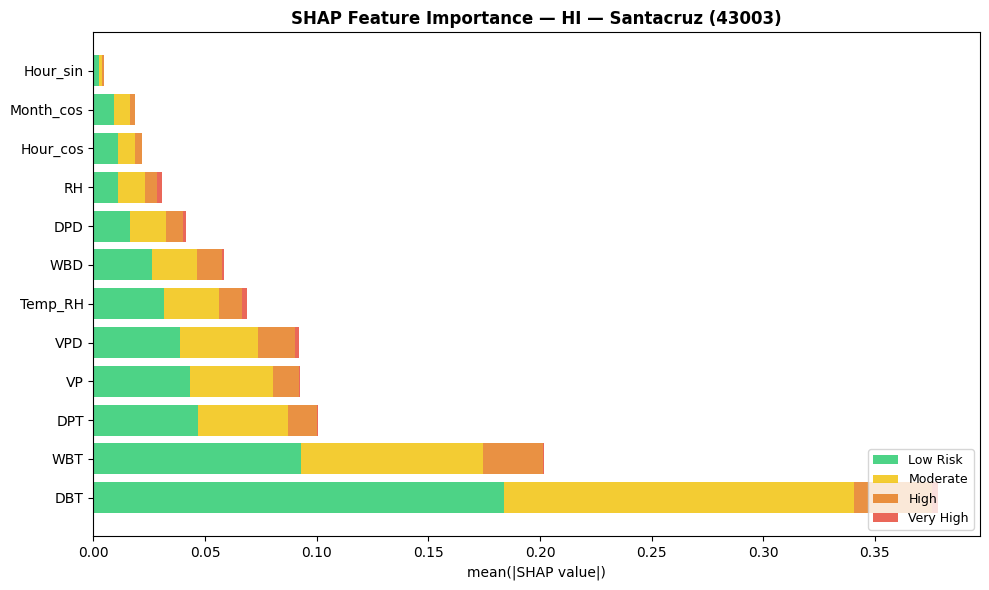

  ✅ SHAP bar HI — Santacruz (43003)


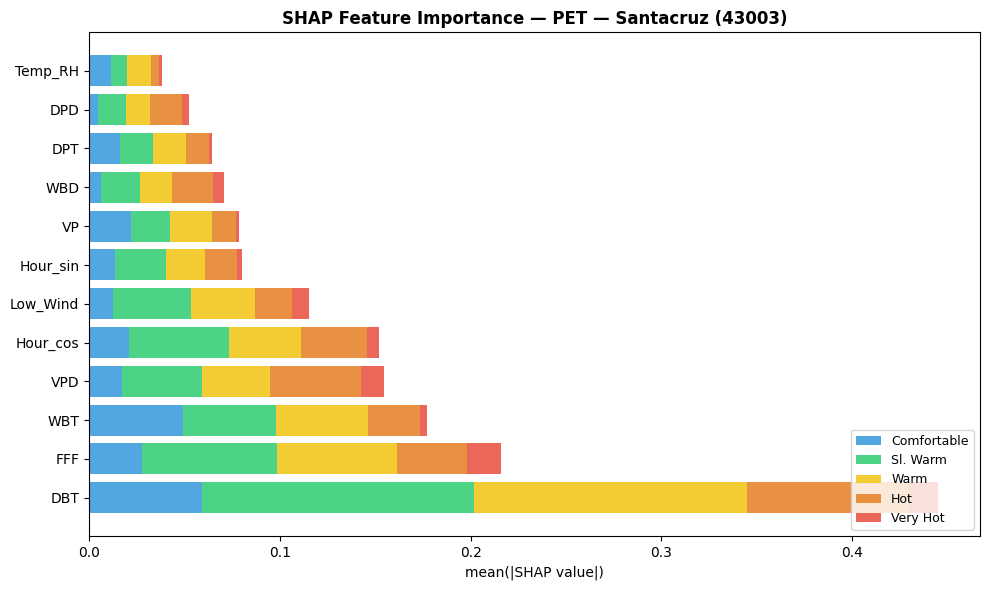

  ✅ SHAP bar PET — Santacruz (43003)

  SHAP — Colaba (43057)


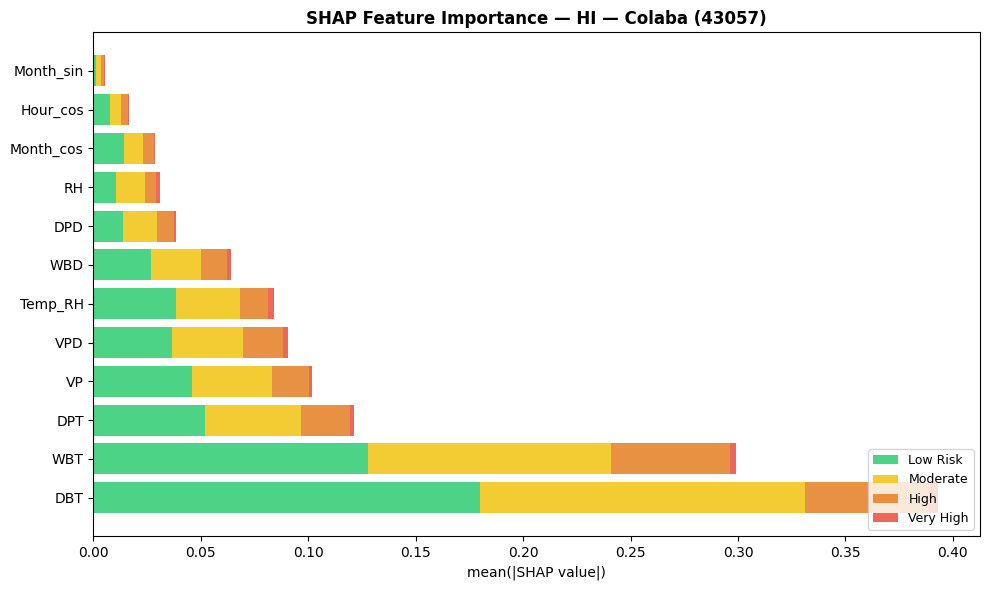

  ✅ SHAP bar HI — Colaba (43057)


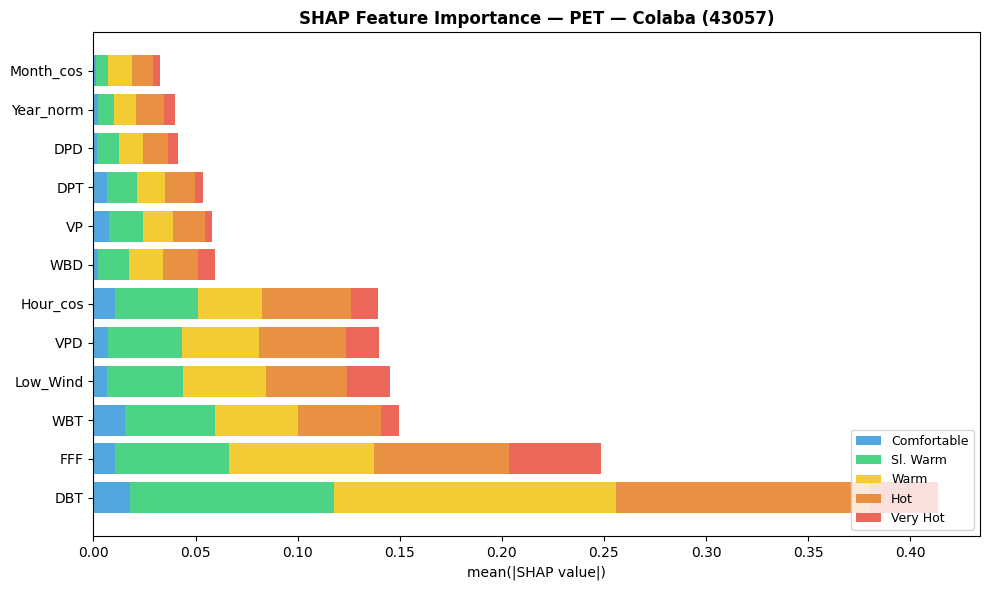

  ✅ SHAP bar PET — Colaba (43057)


In [ ]:
"""
===============================================================================
  VIZ 7: SHAP ANALYSIS — Both Stations Compared
  Feature importance + beeswarm for HI and PET
===============================================================================
"""
shap_results = {}

for sid, meta in STATIONS.items():
    print(f"\n{'='*60}")
    print(f"  SHAP — {meta['label']}")
    print(f"{'='*60}")
    df_c = cleans[sid]
    X_s  = df_c[ALL_FEATURES].values
    shap_results[sid] = {}

    np.random.seed(42)
    shap_n  = 1500
    s_idx   = np.random.choice(len(X_s), size=min(shap_n, len(X_s)), replace=False)
    X_shap  = df_c[ALL_FEATURES].iloc[s_idx].reset_index(drop=True)

    for target_name, y_full in [('HI', df_c['HI_Category'].values),
                                 ('PET', df_c['PET_Category'].values)]:
        rf = RandomForestClassifier(n_estimators=150, random_state=42,
                                    n_jobs=-1, max_depth=12)
        rf.fit(X_s, y_full)
        explainer = shap.TreeExplainer(rf)
        sv_raw    = explainer.shap_values(X_shap)

        # ── Normalize SHAP values to consistent format ──
        # Newer SHAP: 3D array (n_samples, n_features, n_classes)
        # Older SHAP: list of 2D arrays [class0(n_samples, n_features), class1(...), ...]
        sv_arr = np.array(sv_raw)

        if sv_arr.ndim == 3 and sv_arr.shape[2] > 1:
            # 3D: (samples, features, classes) — newer SHAP
            n_classes = sv_arr.shape[2]
            # Convert to list-of-2D for consistent handling
            sv_list = [sv_arr[:, :, c] for c in range(n_classes)]
        elif isinstance(sv_raw, list):
            # Already list of 2D arrays — older SHAP
            sv_list = sv_raw
            n_classes = len(sv_list)
        else:
            # 2D single array (binary or regression)
            sv_list = [sv_arr]
            n_classes = 1

        # Mean absolute SHAP per feature (averaged across classes)
        mean_abs_shap = np.mean([np.abs(s).mean(axis=0) for s in sv_list], axis=0)

        shap_results[sid][target_name] = {
            'mean_abs': mean_abs_shap,
            'features': ALL_FEATURES
        }

        # ── Bar chart ──
        n_classes_actual = len(rf.classes_)
        class_names = ([HI_NAMES[c] for c in rf.classes_] if target_name == 'HI'
                       else [PET_NAMES[c] for c in rf.classes_])
        class_colors_shap = (HI_COLORS[:n_classes_actual] if target_name == 'HI'
                             else PET_COLORS[:n_classes_actual])

        order = np.argsort(mean_abs_shap)[::-1][:12]
        fig, ax = plt.subplots(figsize=(10, 6))
        bottom = np.zeros(len(order))
        for c_i, (cn, cc) in enumerate(zip(class_names, class_colors_shap)):
            if c_i < len(sv_list):
                vals = np.abs(sv_list[c_i]).mean(axis=0)[order]
            else:
                vals = np.zeros(len(order))
            ax.barh(range(len(order)), vals, left=bottom, color=cc,
                    alpha=0.85, label=cn)
            bottom += vals
        ax.set_yticks(range(len(order)))
        ax.set_yticklabels([ALL_FEATURES[i] for i in order])
        ax.set_xlabel('mean(|SHAP value|)')
        ax.set_title(f'SHAP Feature Importance — {target_name} — {meta["label"]}',
                     fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, f'{sid}_shap_bar_{target_name}.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  ✅ SHAP bar {target_name} — {meta["label"]}')

        gc.collect()

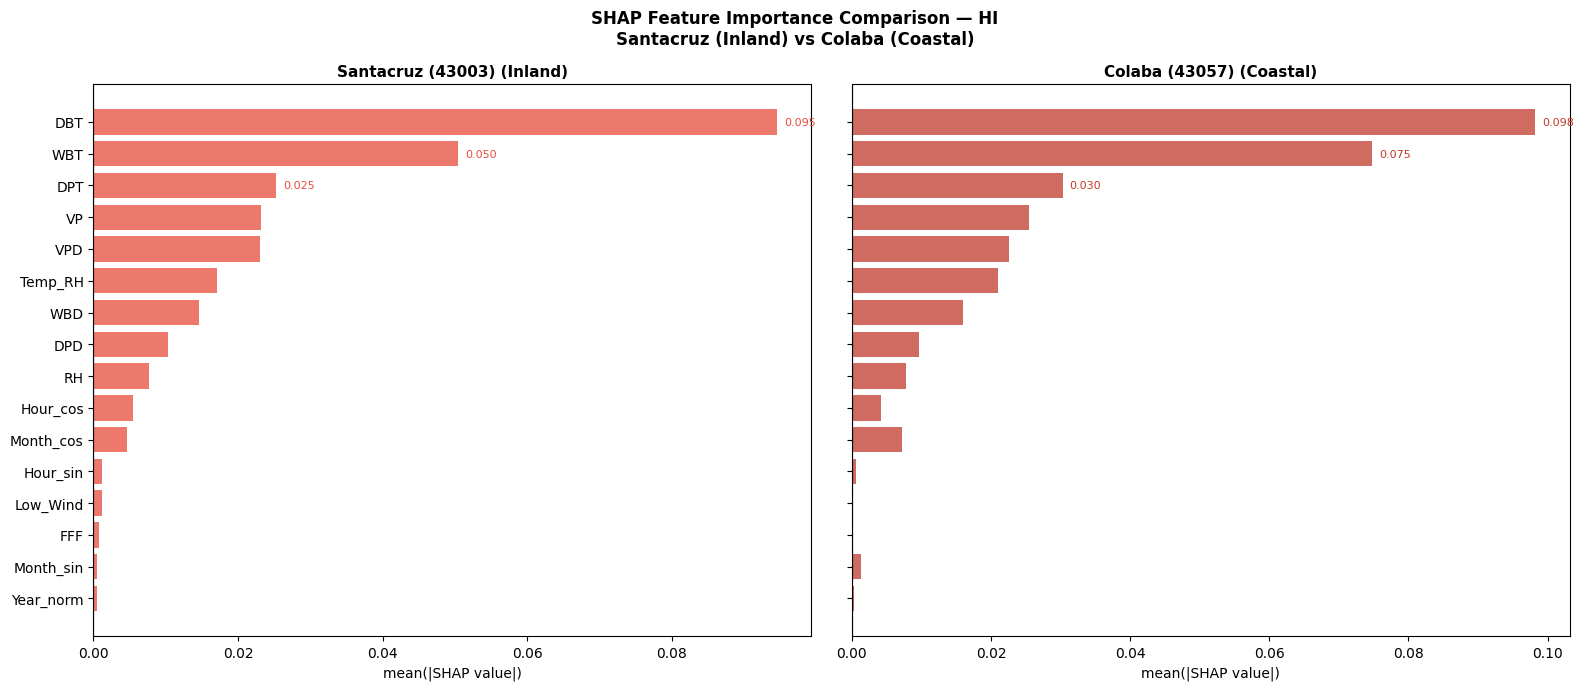

✅ SHAP comparison HI saved


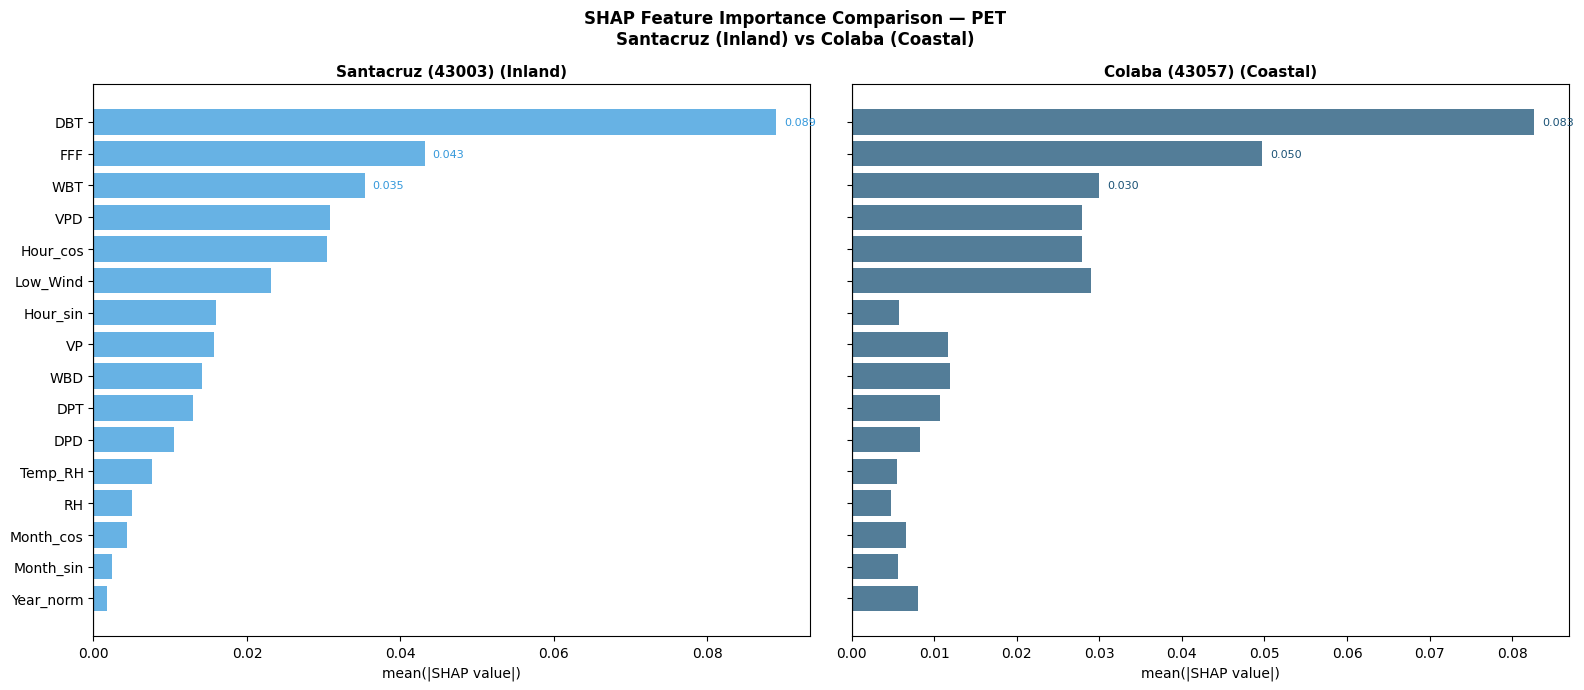

✅ SHAP comparison PET saved


In [ ]:
"""
===============================================================================
  VIZ 8: SHAP COMPARISON — Santacruz vs Colaba Side-by-Side Bar Chart
  Shows which features rank differently between inland vs coastal station
===============================================================================
"""
for target in ['HI', 'PET']:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    fig.suptitle(f'SHAP Feature Importance Comparison — {target}\n'
                 f'Santacruz (Inland) vs Colaba (Coastal)',
                 fontsize=12, fontweight='bold')

    # Use Santacruz feature order as reference
    ref_vals  = shap_results['43003'][target]['mean_abs']
    order     = np.argsort(ref_vals)  # ascending for horizontal bar
    feat_labs = [ALL_FEATURES[i] for i in order]

    for ax, (sid, meta) in zip(axes, STATIONS.items()):
        vals  = shap_results[sid][target]['mean_abs'][order]
        color = meta['color_hi'] if target == 'HI' else meta['color_pet']
        ax.barh(range(len(order)), vals, color=color, alpha=0.75)
        ax.set_yticks(range(len(order)))
        ax.set_yticklabels(feat_labs, fontsize=10)
        ax.set_xlabel('mean(|SHAP value|)', fontsize=10)
        ax.set_title(f"{meta['label']} ({meta['type']})",
                     fontsize=11, fontweight='bold')
        ax.axvline(0, color='black', linewidth=0.8)
        # Annotate top 3
        for rank_i, (val, feat) in enumerate(zip(vals[::-1][:3],
                                                   feat_labs[::-1][:3])):
            ax.text(val + 0.001, len(order)-1-rank_i,
                    f'{val:.3f}', va='center', fontsize=8, color=color)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'comparison_shap_{target}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ SHAP comparison {target} saved')

---
## SECTION C — FEATURE SELECTION (Both Stations)


In [ ]:
"""
===============================================================================
  FEATURE SELECTION — 6 Methods for Both Stations
  Comparison table at the end shows agreed-upon top features
===============================================================================
"""
from sklearn.inspection import permutation_importance

def rank_features(results_dict, feature_names):
    methods = list(results_dict.keys())
    score_df = pd.DataFrame(results_dict, index=feature_names)
    ranked = score_df.copy()
    for m in methods:
        vals = ranked[m].values.astype(float)
        vmin, vmax = vals.min(), vals.max()
        ranked[m] = (vals - vmin) / (vmax - vmin + 1e-12)
    ranked['Avg_Score'] = ranked[methods].mean(axis=1)
    return ranked.sort_values('Avg_Score', ascending=False)


feat_sel_results = {}  # {sid: {HI: df, PET: df}}

for sid, meta in STATIONS.items():
    print(f"\n{'='*60}")
    print(f"  Feature Selection — {meta['label']}")
    print(f"{'='*60}")
    df_c = cleans[sid]
    X_s  = df_c[ALL_FEATURES].values
    feat_sel_results[sid] = {}

    for target_name, y in [('HI', df_c['HI_Category'].values.astype(int)),
                            ('PET', df_c['PET_Category'].values.astype(int))]:
        results = {}
        results['Pearson'] = np.array([abs(np.corrcoef(X_s[:,i], y)[0,1])
                                        for i in range(X_s.shape[1])])
        results['MI']   = mutual_info_classif(X_s, y, random_state=42)
        f_stat, _       = f_classif(X_s, y)
        results['ANOVA'] = np.nan_to_num(f_stat)
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_s, y)
        results['RF_Imp'] = rf.feature_importances_
        gb = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=4)
        gb.fit(X_s, y)
        results['GB_Imp'] = gb.feature_importances_

        if sid in shap_results and target_name in shap_results[sid]:
            results['SHAP'] = shap_results[sid][target_name]['mean_abs']
        else:
            results['SHAP'] = results['RF_Imp']  # fallback

        ranked = rank_features(results, ALL_FEATURES)
        feat_sel_results[sid][target_name] = ranked
        print(f"  {target_name} top 5: {ranked.index[:5].tolist()}")

print("\n✅ Feature selection complete for both stations")


  Feature Selection — Santacruz (43003)
  HI top 5: ['DBT', 'WBT', 'VPD', 'VP', 'DPT']
  PET top 5: ['DBT', 'VPD', 'WBT', 'Hour_cos', 'FFF']

  Feature Selection — Colaba (43057)
  HI top 5: ['WBT', 'DBT', 'VP', 'DPT', 'Temp_RH']
  PET top 5: ['DBT', 'FFF', 'VPD', 'WBT', 'Hour_cos']

✅ Feature selection complete for both stations


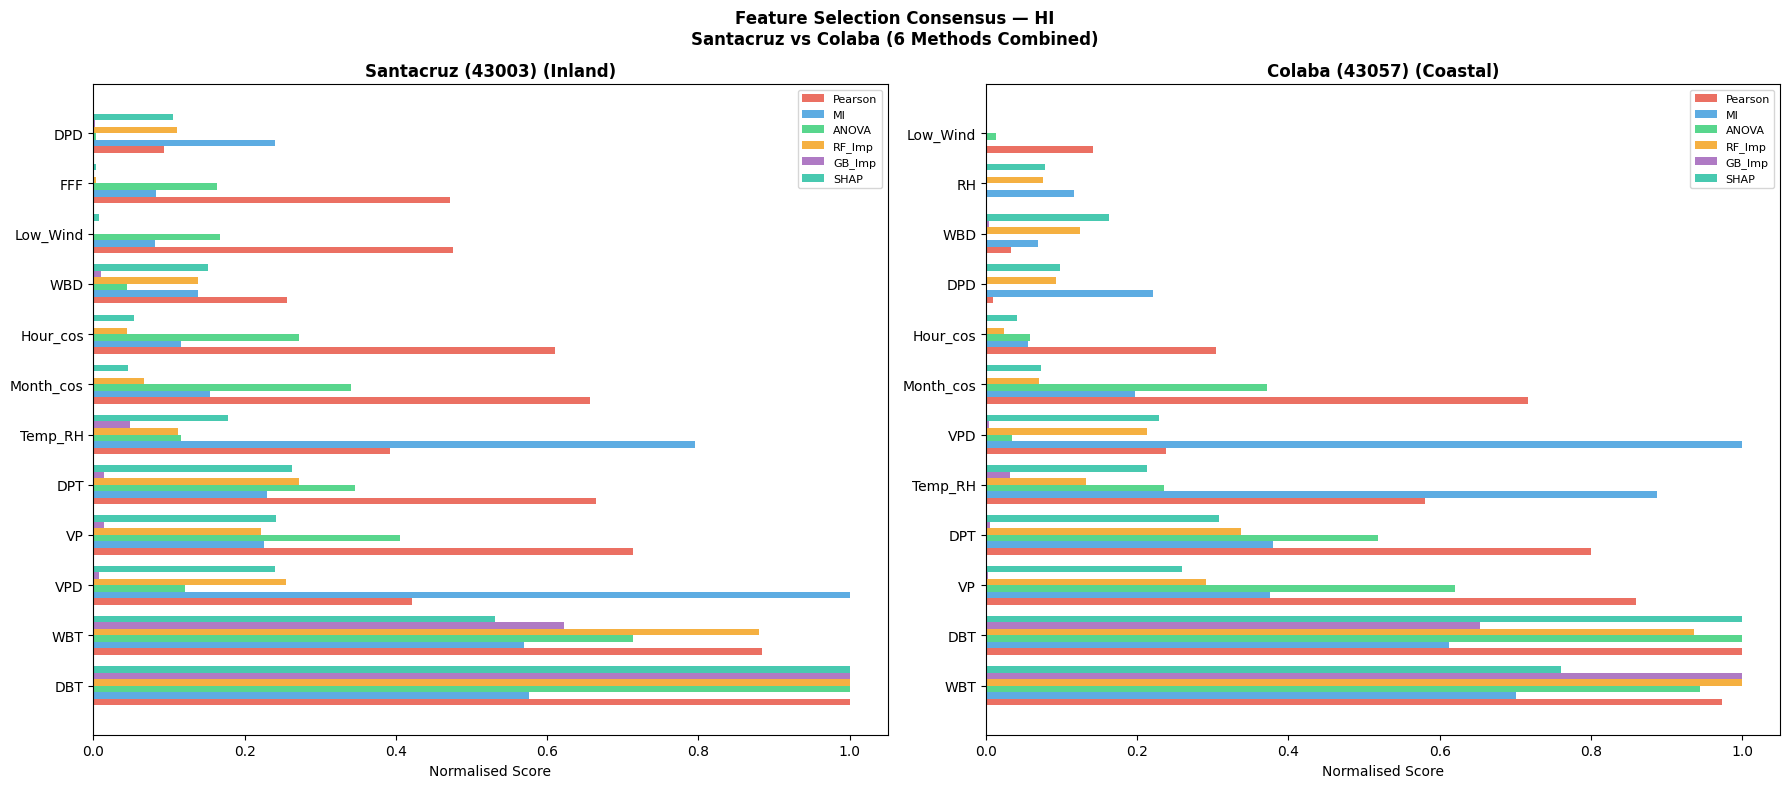

✅ Feature selection comparison HI saved


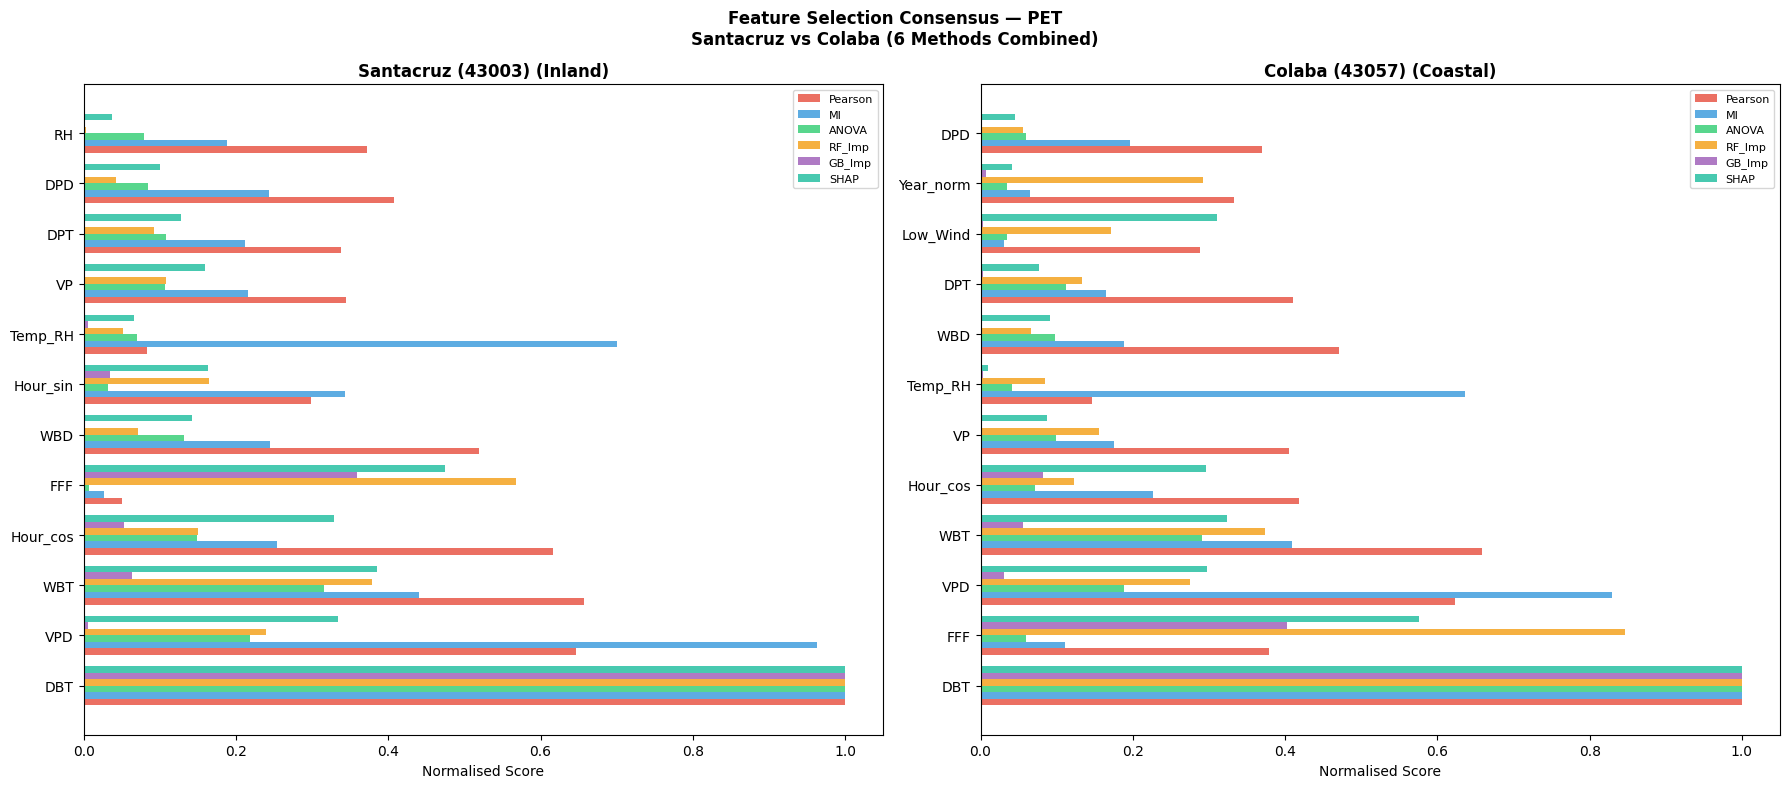

✅ Feature selection comparison PET saved


In [ ]:
"""
===============================================================================
  FEATURE SELECTION COMPARISON — Rank Agreement between Stations
===============================================================================
"""
for target in ['HI', 'PET']:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=False)
    fig.suptitle(f'Feature Selection Consensus — {target}\n'
                 f'Santacruz vs Colaba (6 Methods Combined)',
                 fontsize=12, fontweight='bold')

    for ax, (sid, meta) in zip(axes, STATIONS.items()):
        ranked = feat_sel_results[sid][target]
        top_n  = ranked.head(12)
        methods = ['Pearson','MI','ANOVA','RF_Imp','GB_Imp','SHAP']
        m_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
        y_pos = np.arange(len(top_n))
        h     = 0.13
        for j, (method, mc) in enumerate(zip(methods, m_colors)):
            if method in top_n.columns:
                ax.barh(y_pos + j*h, top_n[method].values, h,
                        label=method, color=mc, alpha=0.8)
        ax.set_yticks(y_pos + (len(methods)-1)*h/2)
        ax.set_yticklabels(top_n.index, fontsize=10)
        ax.set_xlabel('Normalised Score')
        ax.set_title(f"{meta['label']} ({meta['type']})", fontweight='bold')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'comparison_feature_selection_{target}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Feature selection comparison {target} saved')

---
## SECTION D — DATASET SPLITTING (Both Stations)


In [ ]:
"""
===============================================================================
  DATASET SPLITTING — Using Pre-Balanced CSVs from Step 4
  Run for both stations
===============================================================================
"""
split_results = {}

for sid, meta in STATIONS.items():
    print(f"\n{'='*60}")
    print(f"  Dataset Splitting — {meta['label']}")
    print(f"{'='*60}")
    split_results[sid] = {}

    for idx_name in ['HI', 'PET']:
        for balance in ['SMOTE_ENN', 'SMOTE']:
            fpath = os.path.join(
                BALANCED_DIR,
                f'{sid}_{idx_name}_{balance}_balanced.csv'
            )
            if not os.path.exists(fpath):
                print(f'  ⚠  Not found: {os.path.basename(fpath)}')
                continue

            df_bal = pd.read_csv(fpath, low_memory=False)
            feat_cols = [c for c in ALL_FEATURES if c in df_bal.columns]
            cat_col   = f'{idx_name}_Category'
            df_bal    = df_bal[feat_cols + [cat_col]].dropna()

            X_b = df_bal[feat_cols].values
            y_b = df_bal[cat_col].values.astype(int)

            # 70/15/15 stratified split
            X_tr, X_tmp, y_tr, y_tmp = train_test_split(
                X_b, y_b, test_size=0.30, random_state=42, stratify=y_b)
            X_val, X_te, y_val, y_te = train_test_split(
                X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

            split_results[sid][f'{idx_name}_{balance}'] = {
                'train': (X_tr, y_tr),
                'val':   (X_val, y_val),
                'test':  (X_te, y_te)
            }

            print(f"  {idx_name} {balance:10s}: "
                  f"Train={len(y_tr):5d}  Val={len(y_val):4d}  Test={len(y_te):4d}  "
                  f"Classes: {dict(zip(*np.unique(y_tr, return_counts=True)))}")

            # Save splits
            out_base = os.path.join(OUTPUT_DIR, f'{sid}_{idx_name}_{balance}')
            for split_name, (Xs, ys) in [('train',(X_tr,y_tr)),
                                          ('val',(X_val,y_val)),
                                          ('test',(X_te,y_te))]:
                split_df = pd.DataFrame(Xs, columns=feat_cols)
                split_df[cat_col] = ys
                split_df.to_csv(f'{out_base}_{split_name}.csv', index=False)

print("\n✅ All dataset splits saved")

In [ ]:
"""
===============================================================================
  REAL-WORLD TEST SET — Last 10 years (2016–2025), both stations
===============================================================================
"""
print('Building real-world test sets (2016–2025)...')
for sid, meta in STATIONS.items():
    df_c    = cleans[sid]
    rw_test = df_c[df_c['YEAR'] >= 2016]
    rw_path = os.path.join(OUTPUT_DIR, f'{sid}_realworld_test_2016_2025.csv')
    rw_test.to_csv(rw_path, index=False)
    print(f"  {meta['label']}: {len(rw_test)} samples → {os.path.basename(rw_path)}")
    print(f"  HI categories:  {dict(rw_test['HI_Category'].value_counts().sort_index())}")
    print(f"  PET categories: {dict(rw_test['PET_Category'].value_counts().sort_index())}")

print('\n✅ Real-world test sets saved')

Building real-world test sets (2016–2025)...
  Santacruz (43003): 21799 samples → 43003_realworld_test_2016_2025.csv
  HI categories:  {0: np.int64(13263), 1: np.int64(6506), 2: np.int64(2011), 3: np.int64(19)}
  PET categories: {0: np.int64(1173), 1: np.int64(5004), 2: np.int64(9335), 3: np.int64(5179), 4: np.int64(1108)}
  Colaba (43057): 9575 samples → 43057_realworld_test_2016_2025.csv
  HI categories:  {0: np.int64(4898), 1: np.int64(3245), 2: np.int64(1351), 3: np.int64(81)}
  PET categories: {0: np.int64(78), 1: np.int64(1128), 2: np.int64(3444), 3: np.int64(3346), 4: np.int64(1579)}

✅ Real-world test sets saved


In [ ]:
"""
===============================================================================
  SUMMARY — All outputs generated
===============================================================================
"""
import glob
files = sorted(glob.glob(os.path.join(OUTPUT_DIR, '*.png')) +
               glob.glob(os.path.join(OUTPUT_DIR, '*.csv')))
print(f'\n📁 Output directory: {OUTPUT_DIR}')
print(f'   Total files: {len(files)}')
print('\nPaper-replication plots:')
for f in files:
    if 'paper_' in os.path.basename(f):
        print(f'  📊 {os.path.basename(f)}')
print('\nComparison plots:')
for f in files:
    if 'comparison_' in os.path.basename(f):
        print(f'  📈 {os.path.basename(f)}')
print('\nDataset splits (.csv):')
for f in files:
    if f.endswith('.csv'):
        print(f'  💾 {os.path.basename(f)}')


End it here
